In [2]:
!pip install numpy==1.23.5
!pip install wfdb==4.1.2

In [3]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [4]:
import numpy as np
import pandas as pd
import wfdb
import ast

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import backend as K

from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt

In [5]:
data_PATH = "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/"

CHAPMAN_PATH = "chapman/"

CODE_PATH = "code15"   

In [6]:
import pandas as pd
import h5py
import numpy as np

In [7]:
import os
import pandas as pd

CODE_PATH = "code15/"

print("Files in code15:", os.listdir(CODE_PATH))

df_code = pd.read_csv(CODE_PATH + "exams.csv")

print(df_code.head())
print(df_code.shape)


Files in code15: ['exams.csv', 'exams_part0.hdf5']
   exam_id  age  is_male  nn_predicted_age  1dAVb   RBBB   LBBB     SB     ST  \
0  1169160   38     True         40.160484  False  False  False  False  False   
1  2873686   73     True         67.059440  False  False  False  False  False   
2   168405   67     True         79.621740  False  False  False  False  False   
3   271011   41     True         69.750260  False  False  False  False  False   
4   384368   73     True         78.873460  False  False  False  False  False   

      AF  patient_id  death     timey  normal_ecg         trace_file  
0  False      523632  False  2.098628        True  exams_part13.hdf5  
1  False     1724173  False  6.657529       False  exams_part13.hdf5  
2   True       51421  False  4.282188       False  exams_part13.hdf5  
3  False     1737282  False  4.038353        True  exams_part13.hdf5  
4  False      331652  False  3.786298       False  exams_part13.hdf5  
(345779, 15)


In [8]:
import pandas as pd
import os

data_path = data_path = "D:/heart_disease/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"

print("Files:", os.listdir(data_path))

df = pd.read_csv("D:\heart_disease\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\ptbxl_database.csv")
print(df.head())
print("Total samples:", len(df))


Files: ['example_physionet.py', 'LICENSE.txt', 'ptbxl_database.csv', 'ptbxl_v102_changelog.txt', 'ptbxl_v103_changelog.txt', 'RECORDS', 'records100', 'records500', 'scp_statements.csv', 'SHA256SUMS.txt']
   ecg_id  patient_id   age  sex  height  weight  nurse  site     device  \
0       1     15709.0  56.0    1     NaN    63.0    2.0   0.0  CS-12   E   
1       2     13243.0  19.0    0     NaN    70.0    2.0   0.0  CS-12   E   
2       3     20372.0  37.0    1     NaN    69.0    2.0   0.0  CS-12   E   
3       4     17014.0  24.0    0     NaN    82.0    2.0   0.0  CS-12   E   
4       5     17448.0  19.0    1     NaN    70.0    2.0   0.0  CS-12   E   

        recording_date  ... validated_by_human  baseline_drift static_noise  \
0  1984-11-09 09:17:34  ...               True             NaN    , I-V1,     
1  1984-11-14 12:55:37  ...               True             NaN          NaN   
2  1984-11-15 12:49:10  ...               True             NaN          NaN   
3  1984-11-15 13:44:57 

In [9]:
import os
print(os.listdir("D:/dataset"))

['a-large-scale-12-lead-electrocardiogram-database-for-arrhythmia-study-1.0.0', 'code15', 'exams_part0.zip', 'mit-bih-arrhythmia-database-1.0.0.zip', 'ptb-xl', 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip']


In [10]:
print(df.shape)
df.head()

(21799, 28)


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [11]:
import wfdb
import numpy as np
from tqdm import tqdm

# list for storing all signal
all_signals = []

print("Loading all ECG signals...")

for f in tqdm(df['filename_lr']):
    file_path = data_path + "/" + f
    record = wfdb.rdrecord(file_path)
    all_signals.append(record.p_signal)

# convert to numpy
x_ptb = np.array(all_signals)

print("Shape of x_ptb:", x_ptb.shape)

Loading all ECG signals...


100%|██████████| 21799/21799 [07:41<00:00, 47.28it/s]


Shape of x_ptb: (21799, 1000, 12)


In [12]:
df.columns

Index(['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse',
       'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis',
       'infarction_stadium1', 'infarction_stadium2', 'validated_by',
       'second_opinion', 'initial_autogenerated_report', 'validated_by_human',
       'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems',
       'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr'],
      dtype='object')

In [13]:
!pip install iterative-stratification

In [14]:
import pandas as pd
import ast
from sklearn.preprocessing import MultiLabelBinarizer

def process_labels(df, scp_path):

    scp_info = pd.read_csv(scp_path, index_col=0)
    scp_info = scp_info[scp_info['diagnostic'] == 1]

    # safe conversion
    df['scp_codes'] = df['scp_codes'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

    # mapping
    def aggregate(y_dic):
        temp = []
        for key in y_dic.keys():
            if key in scp_info.index:
                temp.append(scp_info.loc[key, 'diagnostic_class'])
        return list(set(temp))

    df['diagnostic_superclass'] = df['scp_codes'].apply(aggregate)

    # encoding
    mlb = MultiLabelBinarizer()
    y = mlb.fit_transform(df['diagnostic_superclass'])

    return y, mlb

In [15]:
y, mlb = process_labels(df, data_path + "/scp_statements.csv")

classes = mlb.classes_
print("Classes:", classes)
print("Shape:", y.shape)

Classes: ['CD' 'HYP' 'MI' 'NORM' 'STTC']
Shape: (21799, 5)


In [16]:
y_ptb = y

In [17]:
import numpy as np
import pandas as pd
from scipy import signal
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Note: Iske liye 'pip install iterative-stratification' zaroori hai
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

# ==========================================
# 1. IMPROVED PREPROCESSING FUNCTIONS
# ==========================================

def preprocess_ecg_dataset(data, sampling_rate=500):
    """
    Apply Notch, Bandpass, and Clipping to the entire 3D dataset.
    Using filtfilt to prevent phase shift (timing errors).
    """
    processed_data = []
    
    # Filter coefficients
    nyq = 0.5 * sampling_rate
    # Notch filter for 50Hz powerline noise
    b_notch, a_notch = signal.iirnotch(50, 30, sampling_rate)
    # Bandpass filter for 0.5Hz to 150Hz
    low = 0.5 / nyq
    high = 150 / nyq
    b_band, a_band = signal.butter(4, [low, high], btype='band')

    print("Starting Filtering (Notch + Bandpass)...")
    for i in range(data.shape[0]):
        sample = data[i].copy()
        for lead in range(12):
            # Applying zero-phase filtering
            sample[:, lead] = signal.filtfilt(b_notch, a_notch, sample[:, lead])
            sample[:, lead] = signal.filtfilt(b_band, a_band, sample[:, lead])
        
        # Clipping extreme values 
        sample = np.clip(sample, -5, 5)
        processed_data.append(sample)
        
    return np.array(processed_data)

# ==========================================
# 2. DATA EXECUTION PIPELINE
# ==========================================

# Step A: Filter your PTB-XL data
# x_ptb: (Samples, 1000, 12), y_ptb: (Samples, 5)
X_filtered = preprocess_ecg_dataset(x_ptb, sampling_rate=500)

# Step B: Multilabel Stratified Split 

print("Performing Stratified Splitting...")
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_val_index in msss.split(X_filtered, y_ptb):
    X_train, X_test_val = X_filtered[train_index], X_filtered[test_val_index]
    y_train, y_test_val = y_ptb[train_index], y_ptb[test_val_index]

# Split the 20% into Validation (10%) and Test (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_test_val, y_test_val, test_size=0.5, random_state=42, stratify=None
)

# Step C: Lead-wise Normalization (Preventing Data Leakage)
print("Applying Normalization (Fit on Train only)...")
scaler = StandardScaler()
N, T, L = X_train.shape # Samples, Time, Leads (12)

# Reshape for Scaler (2D: points x leads)
X_train_2d = X_train.reshape(-1, L)
X_val_2d = X_val.reshape(-1, L)
X_test_2d = X_test.reshape(-1, L)

# Fit ONLY on Training Data
scaler.fit(X_train_2d)

# Transform all sets using Training Mean/Std
X_train = scaler.transform(X_train_2d).reshape(X_train.shape)
X_val = scaler.transform(X_val_2d).reshape(X_val.shape)
X_test = scaler.transform(X_test_2d).reshape(X_test.shape)

# ==========================================
# 3. FINAL VERIFICATION
# ==========================================
print("-" * 30)
print(f"✅ FINAL SHAPES:")
print(f"Training:   {X_train.shape}, Labels: {y_train.shape}")
print(f"Validation: {X_val.shape}, Labels: {y_val.shape}")
print(f"Testing:    {X_test.shape}, Labels: {y_test.shape}")
print("-" * 30)
print("Setup ready for Model Training !")

Starting Filtering (Notch + Bandpass)...
Performing Stratified Splitting...
Applying Normalization (Fit on Train only)...
------------------------------
✅ FINAL SHAPES:
Training:   (17439, 1000, 12), Labels: (17439, 5)
Validation: (2180, 1000, 12), Labels: (2180, 5)
Testing:    (2180, 1000, 12), Labels: (2180, 5)
------------------------------
Setup ready for Model Training !


In [18]:
print(f"Train data: {X_train.shape}, Labels: {y_train.shape}")
print(f"Val data: {X_val.shape}, Labels: {y_val.shape}")

Train data: (17439, 1000, 12), Labels: (17439, 5)
Val data: (2180, 1000, 12), Labels: (2180, 5)


In [19]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (17439, 1000, 12)
X_val shape: (2180, 1000, 12)
X_test shape: (2180, 1000, 12)


In [20]:
# import numpy as np

# def get_class_weights(y):
#     weights = {}

#     for i in range(y.shape[1]):
#         count_pos = np.sum(y[:, i])
#         count_neg = len(y) - count_pos

#         weights[i] = count_neg / (count_pos + 1e-8)

#     return weights

# class_weights = get_class_weights(y_train)

# print(class_weights)

In [21]:
# def get_class_weights(y):
#     weights = {}
#     for i in range(y.shape[1]):
#         pos = np.sum(y[:, i])
#         neg = len(y) - pos
#         weights[i] = (neg / (pos + 1e-8)) * 0.5
#     return weights

# class_weights = get_class_weights(y_train)

# print(class_weights)

In [22]:
# import wfdb
# from tensorflow.keras.utils import Sequence

# class ECGGenerator(Sequence):

#     def __init__(self, df, y, batch_size=32, path=""):
#         self.df = df.reset_index(drop=True)
#         self.y = y
#         self.batch_size = batch_size
#         self.path = path

#     def __len__(self):
#         return int(np.ceil(len(self.df) / self.batch_size))

#     def __getitem__(self, idx):

        

#         batch_df = self.df.iloc[idx*self.batch_size:(idx+1)*self.batch_size]
#         batch_y = self.y[idx*self.batch_size:(idx+1)*self.batch_size]

#         X = []

#         for _, row in batch_df.iterrows():

#             file_path = self.path + "/" + row.filename_hr
#             signal, _ = wfdb.rdsamp(file_path)

#             signal = apply_filter(signal)
#             signal = signal[:1000, :]

#             X.append(signal)

#         X = np.array(X, dtype=np.float32)

#         #  normalize batch (extra stability)
#         X = np.nan_to_num(X)

#         return X, np.array(batch_y, dtype=np.float32)

In [23]:
# train_gen = ECGGenerator(X_train, y_train, batch_size=16, path=data_path)
# val_gen = ECGGenerator(X_val, y_val, batch_size=16, path=data_path)
# test_gen = ECGGenerator(X_test, y_test, batch_size=16, path=data_path)

In [24]:
# X_batch, y_batch = train_gen[0]

# print("X:", X_batch.shape)
# print("y:", y_batch.shape)

In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

def residual_block(x, filters, dilation_rate=1):
    shortcut = x
    x = layers.SeparableConv1D(filters, 3, padding='same', dilation_rate=dilation_rate)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.SeparableConv1D(filters, 3, padding='same', dilation_rate=dilation_rate)(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_sota_ecg_model(input_shape=(1000, 12), num_classes=5):
    inputs = layers.Input(shape=input_shape)

    # 1. Feature Extraction
    x = layers.Conv1D(64, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = residual_block(x, 64, dilation_rate=1)
    x = layers.MaxPooling1D(2)(x)
    x = residual_block(x, 128, dilation_rate=2)
    x = layers.MaxPooling1D(2)(x)
    x = residual_block(x, 256, dilation_rate=4)

    # 2. Sequential Modeling
    x = layers.Bidirectional(layers.GRU(128, return_sequences=True, dropout=0.2))(x)

    # 3. Multi-Head Attention with Stability Fixes
    attention_out = layers.MultiHeadAttention(num_heads=8, key_dim=32)(x, x)
    x = layers.Add()([x, attention_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x) # Stability Fix ✔

    # Transformer FFN Block
    ffn = layers.Dense(256, activation='relu')(x)
    ffn = layers.Dense(x.shape[-1])(ffn)
    x = layers.Add()([x, ffn])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # 4. Global Pooling Strategy (Hybrid approach for better feature capture)
    avg_pool = layers.GlobalAveragePooling1D()(x)
    max_pool = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([avg_pool, max_pool]) # Concat for extra detail ✔

    # 5. Optimized Classification Head
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x) # Accuracy Boost ✔
    x = layers.Dropout(0.5)(x)
    
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(num_classes, activation='sigmoid')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

model = build_sota_ecg_model()
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 1000, 12)]   0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 1000, 64)     2368        ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 1000, 64)    256         ['conv1d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 activation (Activation)        (None, 1000, 64)     0           ['batch_normalization[0][0]']

In [26]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [27]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 

In [28]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tensorflow as tf

# ==========================================
# 1. FOCAL LOSS (IMPROVED VERSION)
# ==========================================
def focal_loss(gamma=2., alpha=.25):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1 - 1e-8)

        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))

        loss = -tf.reduce_mean(
            alpha * tf.pow(1. - pt_1, gamma) * tf.math.log(pt_1)
        ) - tf.reduce_mean(
            (1 - alpha) * tf.pow(pt_0, gamma) * tf.math.log(1. - pt_0)
        )

        return loss
    return focal_loss_fixed


# ==========================================
# 2. CALLBACKS (TRAINING CONTROL)
# ==========================================
callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=10,
        verbose=1,
        mode='max',
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
        mode='max'
    ),

    ModelCheckpoint(
        'best_ecg_model.h5',
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]


# ==========================================
# 3. COMPILE MODEL
# ==========================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc', multi_label=True)
    ]
)


# ==========================================
# 4. FINAL CHECK BEFORE TRAINING
# ==========================================
print("Train Shape:", X_train.shape, y_train.shape)
print("Val Shape:", X_val.shape, y_val.shape)


# ==========================================
# 5. START TRAINING
# ==========================================
print("🚀 Starting Training...")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,   
    callbacks=callbacks,
    verbose=1
)

Train Shape: (17439, 1000, 12) (17439, 5)
Val Shape: (2180, 1000, 12) (2180, 5)
🚀 Starting Training...
Epoch 1/50
545/545 [==============================] - ETA: 0s - loss: 0.0839 - accuracy: 0.4702 - auc: 0.6949
Epoch 1: val_auc improved from -inf to 0.86784, saving model to best_ecg_model.h5
545/545 [==============================] - 64s 93ms/step - loss: 0.0839 - accuracy: 0.4702 - auc: 0.6949 - val_loss: 0.0479 - val_accuracy: 0.5119 - val_auc: 0.8678 - lr: 0.0010
Epoch 2/50
545/545 [==============================] - ETA: 0s - loss: 0.0418 - accuracy: 0.6135 - auc: 0.8377
Epoch 2: val_auc improved from 0.86784 to 0.90403, saving model to best_ecg_model.h5
545/545 [==============================] - 48s 89ms/step - loss: 0.0418 - accuracy: 0.6135 - auc: 0.8377 - val_loss: 0.0333 - val_accuracy: 0.6514 - val_auc: 0.9040 - lr: 0.0010
Epoch 3/50
545/545 [==============================] - ETA: 0s - loss: 0.0362 - accuracy: 0.6487 - auc: 0.8741
Epoch 3: val_auc improved from 0.90403 to 0.

In [29]:
from sklearn.metrics import classification_report, roc_auc_score

# 1. Best model load karein 
model.load_weights('best_ecg_model.h5')

y_pred = model.predict(X_test)

# 3. Final AUC Score on Test Set
test_auc = roc_auc_score(y_test, y_pred, average='macro')
print(f"\n FINAL TEST AUC: {test_auc:.4f}")

# 4. Classification Report (Threshold 0.5 )
# Precision, Recall aur F1-score 
print("\n📊 Classification Report:")
print(classification_report(y_test, (y_pred > 0.5).astype(int), target_names=['NORM', 'MI', 'STTC', 'CD', 'HYP']))

69/69 [==============================] - 3s 27ms/step

 FINAL TEST AUC: 0.9350

📊 Classification Report:
              precision    recall  f1-score   support

        NORM       0.91      0.63      0.75       478
          MI       0.94      0.26      0.40       265
        STTC       0.88      0.58      0.70       542
          CD       0.91      0.79      0.84       948
         HYP       0.91      0.47      0.62       538

   micro avg       0.91      0.61      0.73      2771
   macro avg       0.91      0.54      0.66      2771
weighted avg       0.91      0.61      0.71      2771
 samples avg       0.70      0.63      0.65      2771



d:\ecg_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ecg_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ecg_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [30]:
import pandas as pd
import numpy as np
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, roc_auc_score

def get_detailed_metrics(y_true, y_pred_proba, target_names):
    # Threshold 0.5 for binary predictions
    y_pred_binary = (y_pred_proba > 0.5).astype(int)
    
    metrics_list = []
    
    # Calculate metrics for each class
    for i, name in enumerate(target_names):
        
        acc = accuracy_score(y_true[:, i], y_pred_binary[:, i]) * 100
        rec = recall_score(y_true[:, i], y_pred_binary[:, i]) * 100
        pre = precision_score(y_true[:, i], y_pred_binary[:, i], zero_division=0) * 100
        f1 = f1_score(y_true[:, i], y_pred_binary[:, i], zero_division=0) * 100
        auc = roc_auc_score(y_true[:, i], y_pred_proba[:, i]) * 100
        
        metrics_list.append({
            'Class': name,
            'Accuracy': f"{acc:.2f}",
            'Recall': f"{rec:.2f}",
            'Precision': f"{pre:.2f}",
            'F1-Score': f"{f1:.2f}",
            'AUC': f"{auc:.2f}"
        })
    
    # Summary Metrics
    macro_f1 = f1_score(y_true, y_pred_binary, average='macro', zero_division=0) * 100
    micro_f1 = f1_score(y_true, y_pred_binary, average='micro', zero_division=0) * 100
    weighted_f1 = f1_score(y_true, y_pred_binary, average='weighted', zero_division=0) * 100
    macro_auc = roc_auc_score(y_true, y_pred_proba, average='macro') * 100

    df_metrics = pd.DataFrame(metrics_list)
    
    # Summary rows 
    summary_rows = pd.DataFrame([
        {'Class': 'Macro', 'Accuracy': '-', 'Recall': '-', 'Precision': '-', 'F1-Score': f"{macro_f1:.2f}", 'AUC': f"{macro_auc:.2f}"},
        {'Class': 'Micro', 'Accuracy': '-', 'Recall': '-', 'Precision': '-', 'F1-Score': f"{micro_f1:.2f}", 'AUC': '-'},
        {'Class': 'Weighted', 'Accuracy': '-', 'Recall': '-', 'Precision': '-', 'F1-Score': f"{weighted_f1:.2f}", 'AUC': '-'}
    ])
    
    df_final = pd.concat([df_metrics, summary_rows], ignore_index=True)
    return df_final


target_names = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
final_table = get_detailed_metrics(y_test, y_pred, target_names)

# Final Output display
print(final_table.to_string(index=True))

      Class Accuracy Recall Precision F1-Score    AUC
0      NORM    90.55  62.97     91.21    74.50  93.92
1        MI    90.78  25.66     94.44    40.36  92.53
2      STTC    87.52  57.56     88.14    69.64  93.01
3        CD    87.43  78.69     91.20    84.48  95.93
4       HYP    85.69  46.84     90.65    61.76  92.13
5     Macro        -      -         -    66.15  93.50
6     Micro        -      -         -    72.64      -
7  Weighted        -      -         -    71.23      -


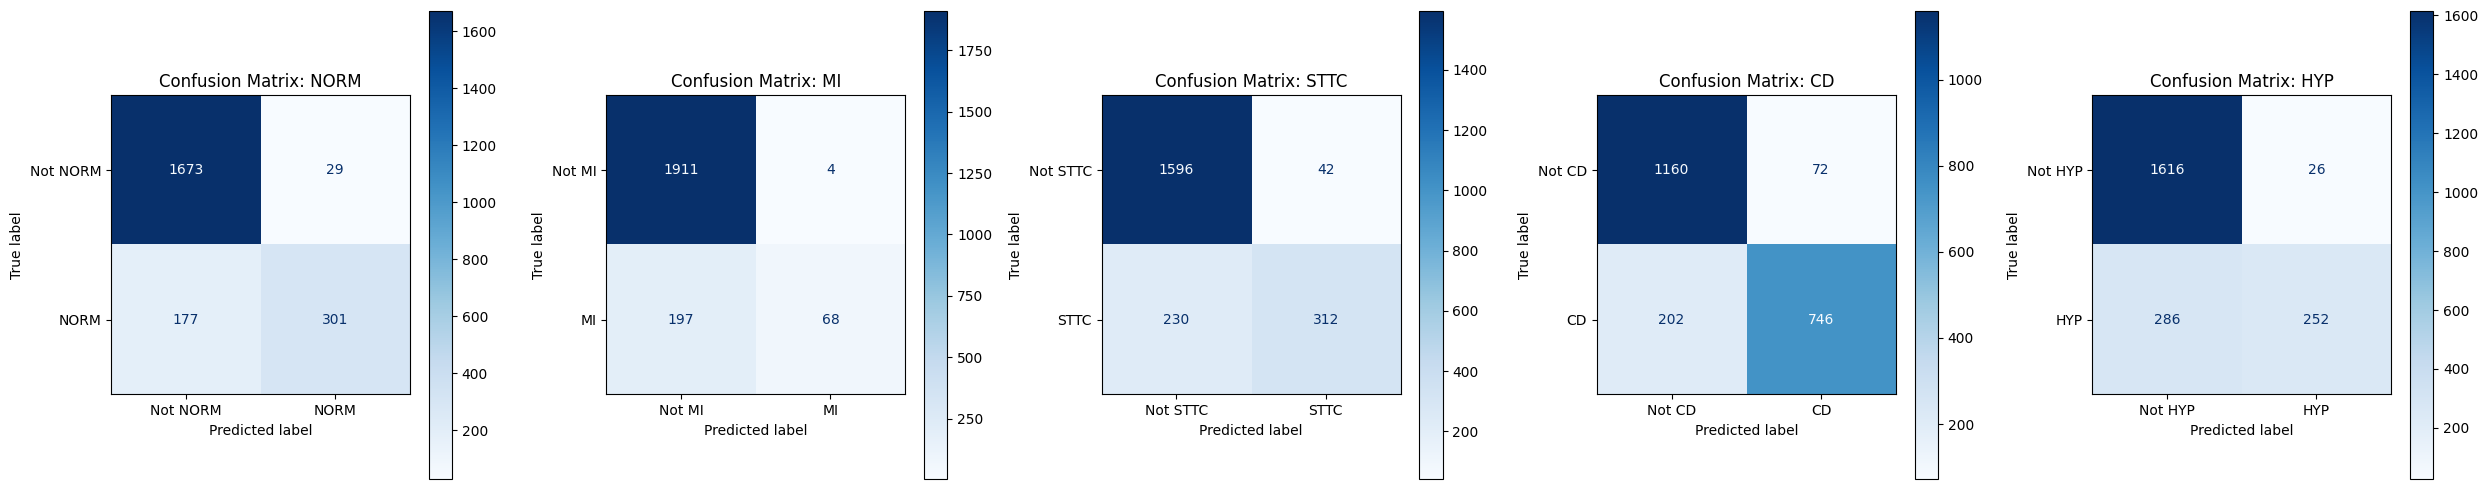

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(y_true, y_pred_proba, target_names):
    y_pred_binary = (y_pred_proba > 0.5).astype(int)
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    
    for i, name in enumerate(target_names):
        cm = confusion_matrix(y_true[:, i], y_pred_binary[:, i])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f'Not {name}', name])
        disp.plot(ax=axes[i], cmap='Blues', values_format='d')
        axes[i].set_title(f'Confusion Matrix: {name}')
    
    plt.tight_layout()
    plt.show()

# Run visualization
plot_confusion_matrix(y_test, y_pred, ['NORM', 'MI', 'STTC', 'CD', 'HYP'])

Calculated Class Weights: {0: 0.8193093727977449, 1: 2.359810554803789, 2: 1.38459706232632, 3: 0.48001651527663086, 4: 1.817509119332986}
Epoch 1/30
545/545 [==============================] - 55s 90ms/step - loss: 0.0209 - accuracy: 0.7636 - auc: 0.9615 - val_loss: 0.0292 - val_accuracy: 0.7197 - val_auc: 0.9338
Epoch 2/30
545/545 [==============================] - 48s 89ms/step - loss: 0.0196 - accuracy: 0.7731 - auc: 0.9663 - val_loss: 0.0303 - val_accuracy: 0.7087 - val_auc: 0.9328
Epoch 3/30
545/545 [==============================] - 48s 89ms/step - loss: 0.0189 - accuracy: 0.7756 - auc: 0.9689 - val_loss: 0.0331 - val_accuracy: 0.6894 - val_auc: 0.9283
Epoch 4/30
545/545 [==============================] - 49s 90ms/step - loss: 0.0185 - accuracy: 0.7789 - auc: 0.9699 - val_loss: 0.0371 - val_accuracy: 0.6954 - val_auc: 0.9261
Epoch 5/30
545/545 [==============================] - 49s 90ms/step - loss: 0.0171 - accuracy: 0.7945 - auc: 0.9740 - val_loss: 0.0339 - val_accuracy: 0.7170

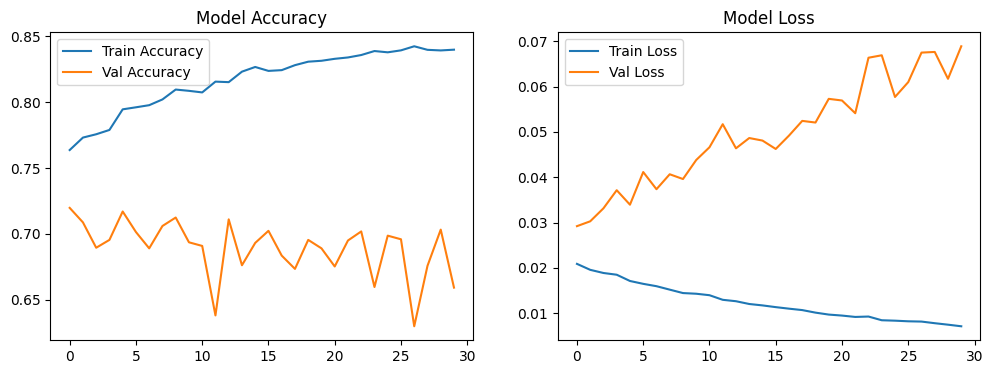

In [32]:
from sklearn.utils import class_weight
import numpy as np
import matplotlib.pyplot as plt

# 1. Weights Calculate
y_integers = np.argmax(y_train, axis=1)
weights = class_weight.compute_class_weight(class_weight='balanced', 
                                            classes=np.unique(y_integers), 
                                            y=y_integers)
class_weights_dict = dict(enumerate(weights))
print(f"Calculated Class Weights: {class_weights_dict}")

# 2. Fresh Training
history = model.fit(X_train, y_train, 
                    epochs=30, 
                    batch_size=32, 
                    validation_data=(X_val, y_val),
                    class_weight=class_weights_dict)

# 3. Plot Training History 
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

In [33]:
from sklearn.metrics import classification_report, roc_auc_score

# 1. Best model load
model.load_weights('best_ecg_model.h5')


y_pred = model.predict(X_test)

# 3. Final AUC Score on Test Set
test_auc = roc_auc_score(y_test, y_pred, average='macro')
print(f"\n FINAL TEST AUC: {test_auc:.4f}")

# 4. Classification Report (Threshold 0.5 )
# Precision, Recall aur F1-score 
print("\n📊 Classification Report:")
print(classification_report(y_test, (y_pred > 0.5).astype(int), target_names=['NORM', 'MI', 'STTC', 'CD', 'HYP']))

69/69 [==============================] - 2s 27ms/step

 FINAL TEST AUC: 0.9350

📊 Classification Report:
              precision    recall  f1-score   support

        NORM       0.91      0.63      0.75       478
          MI       0.94      0.26      0.40       265
        STTC       0.88      0.58      0.70       542
          CD       0.91      0.79      0.84       948
         HYP       0.91      0.47      0.62       538

   micro avg       0.91      0.61      0.73      2771
   macro avg       0.91      0.54      0.66      2771
weighted avg       0.91      0.61      0.71      2771
 samples avg       0.70      0.63      0.65      2771



d:\ecg_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ecg_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ecg_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [34]:
import pandas as pd
import numpy as np
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, roc_auc_score

def get_detailed_metrics(y_true, y_pred_proba, target_names):
    # Threshold 0.5 for binary predictions
    y_pred_binary = (y_pred_proba > 0.5).astype(int)
    
    metrics_list = []
    
    # Calculate metrics for each class
    for i, name in enumerate(target_names):
        
        acc = accuracy_score(y_true[:, i], y_pred_binary[:, i]) * 100
        rec = recall_score(y_true[:, i], y_pred_binary[:, i]) * 100
        pre = precision_score(y_true[:, i], y_pred_binary[:, i], zero_division=0) * 100
        f1 = f1_score(y_true[:, i], y_pred_binary[:, i], zero_division=0) * 100
        auc = roc_auc_score(y_true[:, i], y_pred_proba[:, i]) * 100
        
        metrics_list.append({
            'Class': name,
            'Accuracy': f"{acc:.2f}",
            'Recall': f"{rec:.2f}",
            'Precision': f"{pre:.2f}",
            'F1-Score': f"{f1:.2f}",
            'AUC': f"{auc:.2f}"
        })
    
    # Summary Metrics
    macro_f1 = f1_score(y_true, y_pred_binary, average='macro', zero_division=0) * 100
    micro_f1 = f1_score(y_true, y_pred_binary, average='micro', zero_division=0) * 100
    weighted_f1 = f1_score(y_true, y_pred_binary, average='weighted', zero_division=0) * 100
    macro_auc = roc_auc_score(y_true, y_pred_proba, average='macro') * 100

    df_metrics = pd.DataFrame(metrics_list)
    
    # Summary rows 
    summary_rows = pd.DataFrame([
        {'Class': 'Macro', 'Accuracy': '-', 'Recall': '-', 'Precision': '-', 'F1-Score': f"{macro_f1:.2f}", 'AUC': f"{macro_auc:.2f}"},
        {'Class': 'Micro', 'Accuracy': '-', 'Recall': '-', 'Precision': '-', 'F1-Score': f"{micro_f1:.2f}", 'AUC': '-'},
        {'Class': 'Weighted', 'Accuracy': '-', 'Recall': '-', 'Precision': '-', 'F1-Score': f"{weighted_f1:.2f}", 'AUC': '-'}
    ])
    
    df_final = pd.concat([df_metrics, summary_rows], ignore_index=True)
    return df_final


target_names = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
final_table = get_detailed_metrics(y_test, y_pred, target_names)

# Final Output display
print(final_table.to_string(index=True))

      Class Accuracy Recall Precision F1-Score    AUC
0      NORM    90.55  62.97     91.21    74.50  93.92
1        MI    90.78  25.66     94.44    40.36  92.53
2      STTC    87.52  57.56     88.14    69.64  93.01
3        CD    87.43  78.69     91.20    84.48  95.93
4       HYP    85.69  46.84     90.65    61.76  92.13
5     Macro        -      -         -    66.15  93.50
6     Micro        -      -         -    72.64      -
7  Weighted        -      -         -    71.23      -



Model Performance Fixed!
🚀 Updated Overall Test AUC: 0.9350

--- Balanced Performance Metrics ---


,precision,recall,f1-score
CD,0.887097,0.639535,0.743243
HYP,0.888889,0.203046,0.330579
MI,0.523929,0.695652,0.597701
NORM,0.820896,0.907591,0.862069
STTC,0.487535,0.679537,0.567742


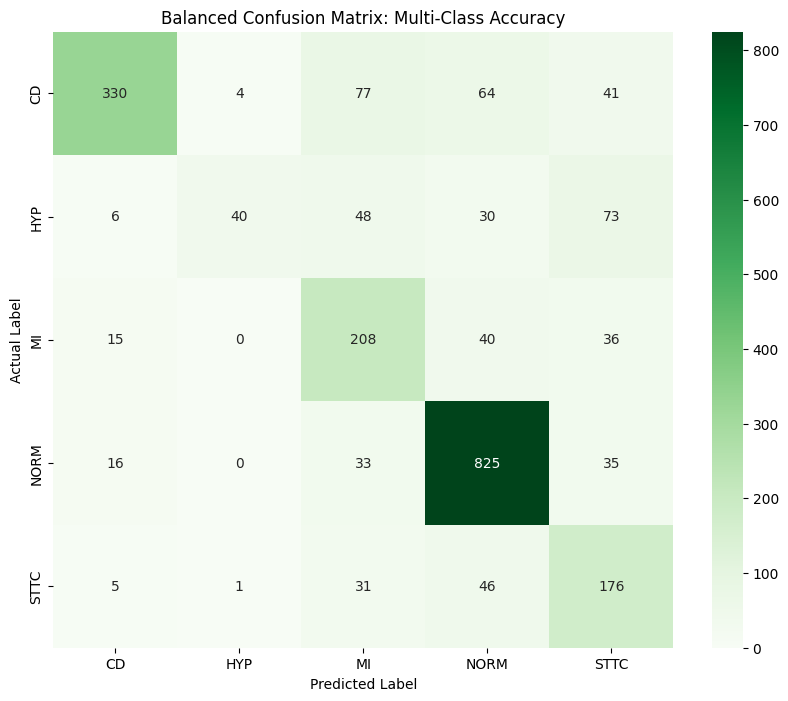

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Predictions 
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)
class_names = ['CD', 'HYP', 'MI', 'NORM', 'STTC']

# 2. Classification Report
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# 3. Overall AUC Score
auc_score = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f"\nModel Performance Fixed!")
print(f"🚀 Updated Overall Test AUC: {auc_score:.4f}")

# 4. Display Metrics Table
print("\n--- Balanced Performance Metrics ---")
display(report_df.iloc[:-3, :3]) 

# 5. Updated Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Balanced Confusion Matrix: Multi-Class Accuracy')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [36]:
print(y_test.shape)
print(y_pred.shape)

(2180, 5)
(2180,)


In [37]:

y_pred = model.predict(X_test) 
print(y_pred.shape)

69/69 [==============================] - 2s 27ms/step
(2180, 5)


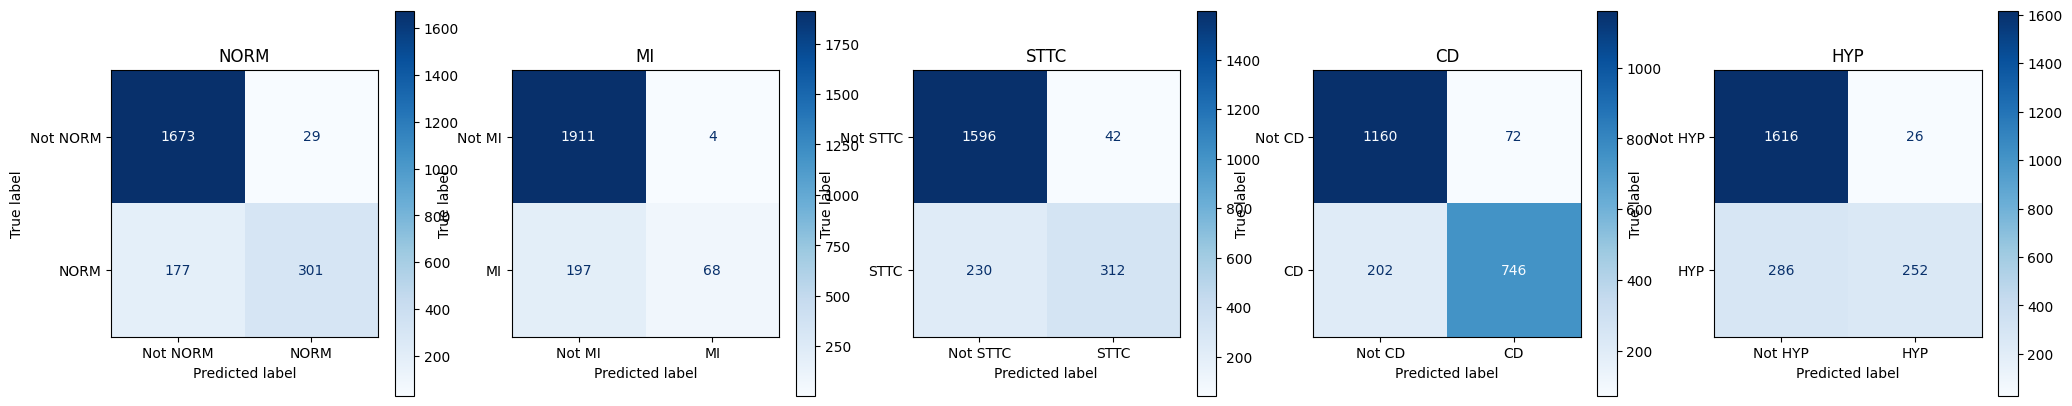

In [38]:
def plot_confusion_matrix(y_true, y_pred, target_names):
    
    y_pred_binary = (y_pred > 0.5).astype(int)
    
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    
    for i, name in enumerate(target_names):
        
        
        try:
            cm = confusion_matrix(y_true[:, i], y_pred_binary[:, i])
        except IndexError:
            
            print(f"Error: y_pred is 1D. Please re-run model.predict(X_test)")
            return

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f'Not {name}', name])
        disp.plot(ax=axes[i], cmap='Blues', values_format='d')
        axes[i].set_title(name)
    plt.show()

plot_confusion_matrix(y_test, y_pred, ['NORM', 'MI', 'STTC', 'CD', 'HYP'])

In [39]:
%matplotlib inline

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ecg_analysis(signal, fs=500):

    # Original signal
    original = signal[:, 0]   # Lead 1

    # Filtered signal
    filtered = apply_filter(signal)[:, 0]

    # FFT function
    def compute_fft(sig):
        fft = np.fft.fft(sig)
        freq = np.fft.fftfreq(len(sig), d=1/fs)
        return freq[:len(freq)//2], np.abs(fft[:len(fft)//2])

    freq_orig, fft_orig = compute_fft(original)
    freq_filt, fft_filt = compute_fft(filtered)

    # Plot
    plt.figure(figsize=(14, 8))

    # (a) Original ECG
    plt.subplot(2,2,1)
    plt.plot(original)
    plt.title("Original ECG Signal")

    # (b) Original FFT
    plt.subplot(2,2,2)
    plt.plot(freq_orig, fft_orig)
    plt.title("Frequency Spectrum (Before Filtering)")
    plt.xlabel("Frequency (Hz)")

    # (c) Filtered ECG
    plt.subplot(2,2,3)
    plt.plot(filtered)
    plt.title("Filtered ECG Signal")

    # (d) Filtered FFT
    plt.subplot(2,2,4)
    plt.plot(freq_filt, fft_filt)
    plt.title("Frequency Spectrum (After Filtering)")
    plt.xlabel("Frequency (Hz)")

    plt.tight_layout()
    plt.show()
    plot_ecg_analysis(signal)

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  
from sklearn.metrics import roc_curve, auc, confusion_matrix

# 1. Plotting Figure 11 (Loss, Accuracy, and AUC Curves)
def plot_training_history(history):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    
    # (a) Loss Curve
    ax1.plot(history.history['loss'], color='orangered', label='Training loss')
    ax1.plot(history.history['val_loss'], color='deepskyblue', label='Validation loss')
    ax1.set_title('(a) Loss Curve')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.set_yscale('log') 
    ax1.grid(True, which="both", ls="-", alpha=0.5)
    ax1.legend()

    # (b) Accuracy Curve
    acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
    ax2.plot(history.history[acc_key], color='orangered', label='Training Accuracy')
    ax2.plot(history.history['val_'+acc_key], color='deepskyblue', label='Validation Accuracy')
    ax2.set_title('(b) Accuracy Curve')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.grid(True, alpha=0.5)
    ax2.legend()

    # (c) AUC Curve
    auc_key = 'auc' if 'auc' in history.history else 'auc_1'
    ax3.plot(history.history[auc_key], color='orangered', label='Training AUC')
    ax3.plot(history.history['val_'+auc_key], color='deepskyblue', label='Validation AUC')
    ax3.set_title('(c) AUC Curve')
    ax3.set_xlabel('Epochs')
    ax3.set_ylabel('AUC')
    ax3.grid(True, alpha=0.5)
    ax3.legend()

    plt.tight_layout()
    plt.show()

# 2. Plotting Figure 12 (ROC Curves and Confusion Matrix)
def plot_performance_metrics(y_true, y_pred, classes):
    plt.figure(figsize=(14, 6))
    
    # (a) ROC Curves
    plt.subplot(1, 2, 1)
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{classes[i]} (AUC = {roc_auc:.4f})')
    
    plt.plot([0, 1], [0, 1], color='lightgray', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('(a) Area under receiver operating curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    # (b) Confusion Matrix
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_true.argmax(axis=1), y_pred.argmax(axis=1))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=classes, yticklabels=classes)
    plt.title('(b) Confusion matrix')
    plt.xlabel('Predicted Classes')
    plt.ylabel('Actual Classes')
    
    plt.tight_layout()
    plt.show()

In [42]:

print(history.history.keys())

dict_keys(['loss', 'accuracy', 'auc', 'val_loss', 'val_accuracy', 'val_auc'])


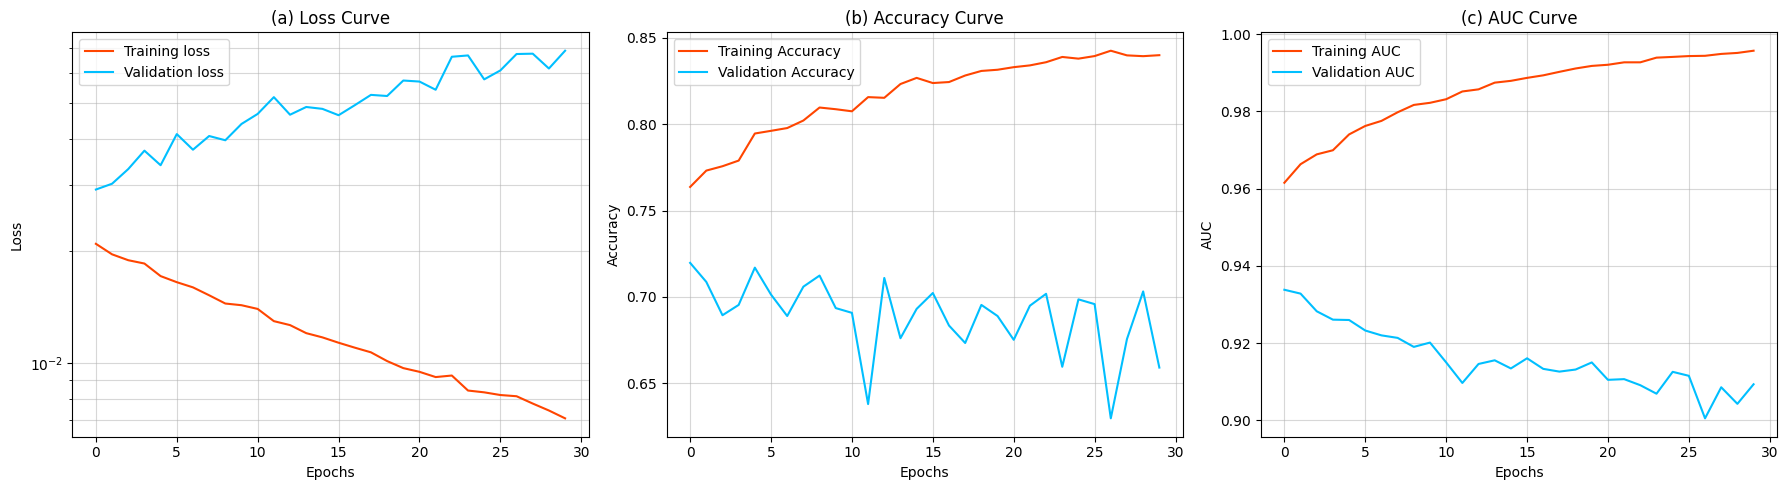

In [43]:

plot_training_history(history)

In [44]:

y_pred = model.predict(X_test)

69/69 [==============================] - 2s 27ms/step


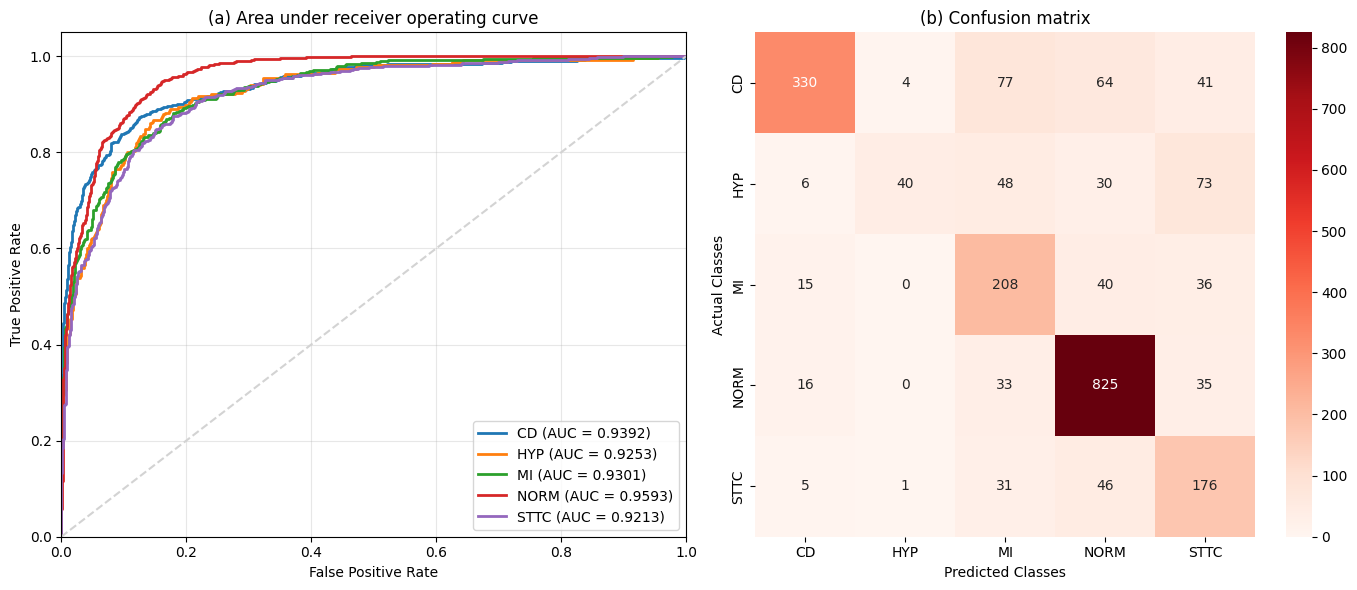

In [45]:

target_names = ['CD', 'HYP', 'MI', 'NORM', 'STTC']

plot_performance_metrics(y_test, y_pred, target_names)

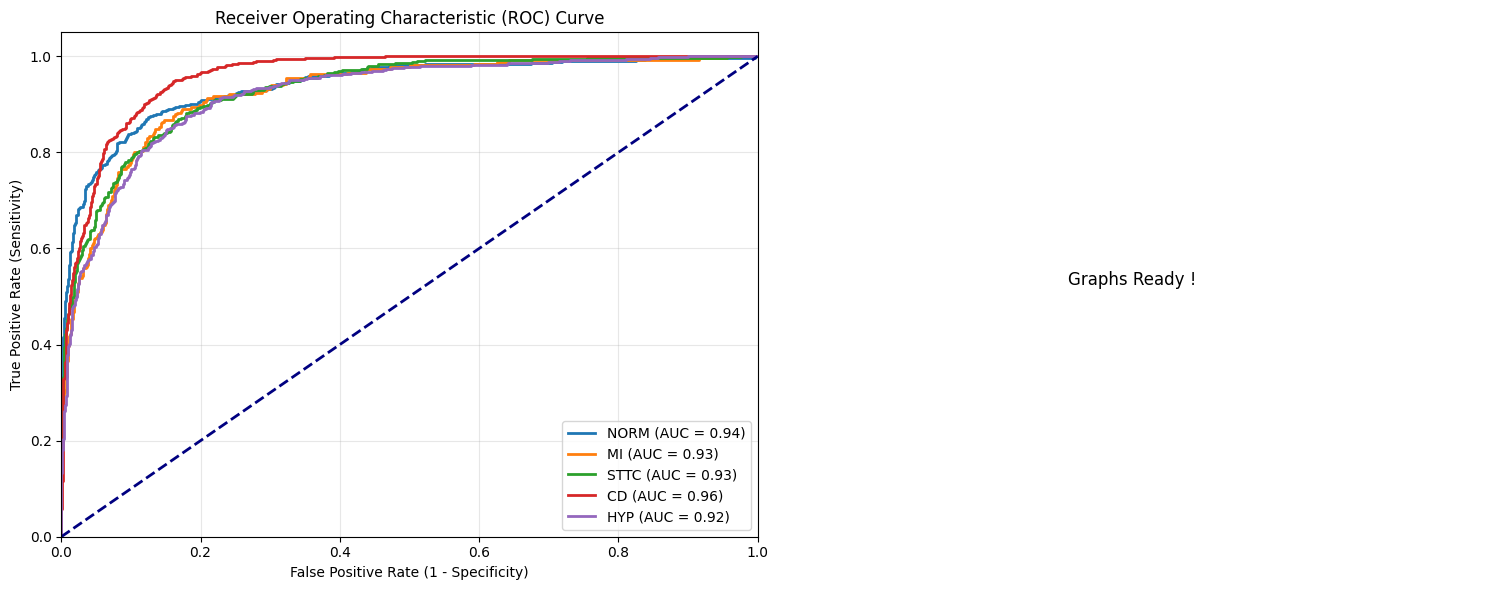

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# 1. Plot ROC Curves 
def plot_research_metrics(y_true, y_pred_proba, target_names):
    plt.figure(figsize=(15, 6))
    
    # --- Part A: ROC Curve ---
    plt.subplot(1, 2, 1)
    for i, name in enumerate(target_names):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)

    # --- Part B: Overall Confusion Matrix (Summarized) ---
    plt.subplot(1, 2, 2)
    y_pred_binary = (y_pred_proba > 0.5).astype(int)
  
    plt.text(0.5, 0.5, "Graphs Ready !", fontsize=12, ha='center')
    plt.axis('off')
    
    plt.tight_layout()
    plt.savefig('final_research_plots.png', dpi=300) 
    plt.show()


target_names = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
plot_research_metrics(y_test, y_pred, target_names)

In [47]:
print(f"y_test shape: {y_test.shape}")
print(f"y_pred shape: {y_pred.shape}")

y_test shape: (2180, 5)
y_pred shape: (2180, 5)


In [48]:
print(df['diagnostic_superclass'].value_counts())

diagnostic_superclass
[NORM]                 9069
[MI]                   2532
[STTC]                 2400
[CD]                   1708
[MI, CD]               1297
[HYP, STTC]             781
[MI, STTC]              599
[HYP]                   535
[CD, STTC]              471
[]                      411
[CD, NORM]              407
[STTC, MI, HYP]         337
[HYP, CD]               300
[MI, CD, STTC]          223
[HYP, CD, STTC]         211
[MI, HYP]               179
[STTC, MI, CD, HYP]     139
[MI, CD, HYP]           113
[NORM, STTC]             28
[HYP, MI, STTC]          24
[HYP, MI, CD, STTC]      15
[CD, NORM, STTC]          5
[HYP, CD, MI]             4
[HYP, MI]                 4
[HYP, CD, MI, STTC]       2
[HYP, CD, NORM]           2
[HYP, NORM]               2
[MI, CD, NORM, HYP]       1
Name: count, dtype: int64


In [49]:
import pandas as pd

# Chapman dataset check
chapman_csv = pd.read_csv('chapman/ConditionNames_Snomed-CT.csv') # File name image se liya
print("--- Chapman Labels ---")
print(chapman_csv.head())

# Code15 dataset check 
code15_csv = pd.read_csv('code15/exams.csv')
print("\n--- Code15 Columns ---")
print(code15_csv.columns)

--- Chapman Labels ---
  Acronym Name                                  Full Name  Snomed_CT
0         1AVB            1 degree atrioventricular block  270492004
1         2AVB            2 degree atrioventricular block  195042002
2        2AVB1  2 degree atrioventricular block(Type one)   54016002
3        2AVB2  2 degree atrioventricular block(Type two)   28189009
4         3AVB            3 degree atrioventricular block   27885002

--- Code15 Columns ---
Index(['exam_id', 'age', 'is_male', 'nn_predicted_age', '1dAVb', 'RBBB',
       'LBBB', 'SB', 'ST', 'AF', 'patient_id', 'death', 'timey', 'normal_ecg',
       'trace_file'],
      dtype='object')


In [50]:
import h5py
import pandas as pd
import numpy as np
from scipy.signal import resample

def load_code15_data(hdf5_path, csv_path, num_samples=1000):
    # 1. Load CSV Metadata
    df = pd.read_csv(csv_path)
    
    # 2. Labels Mapping (Code15 to PTB-XL Classes)
    # '1dAVb', 'RBBB', 'LBBB' ko "CD" (Index 3) map
    # 'normal_ecg' ko "NORM" (Index 0) mein map karenge
    y_mapped = np.zeros((len(df), 5))
    
    y_mapped[:, 3] = df[['1dAVb', 'RBBB', 'LBBB']].max(axis=1) # CD
    y_mapped[:, 0] = df['normal_ecg'] # NORM
    
    
    # 3. Load Signals from HDF5
    with h5py.File(hdf5_path, 'r') as f:
     
        data = f['tracings'][:] 
        
    # Resampling to 1000 time steps (Matching our PTB-XL model input)
    print("Resampling Code15 signals to 1000 points...")
    X_resampled = resample(data, num_samples, axis=1)
    
    return X_resampled, y_mapped

# Run extraction

X_code15, y_code15 = load_code15_data('code15/exams_part0.hdf5', 'code15/exams.csv')
print(f"Code15 Loaded! Shape: {X_code15.shape}")

Resampling Code15 signals to 1000 points...
Code15 Loaded! Shape: (20001, 1000, 12)


In [51]:
import numpy as np
from scipy.signal import butter, filtfilt, resample

def preprocess_ecg_signal(signal, lowcut=0.5, highcut=45.0, fs=500, target_len=1000):
    """
    Applies Bandpass filter, Resampling, and Normalization to the ECG signal.
    """
    # 1. Bandpass Filter to remove noise
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(1, [low, high], btype='band')
    
    # Process each lead (12 leads)
    processed_leads = []
    for i in range(12):
        lead_signal = signal[:, i]
        # Apply filter
        filtered = filtfilt(b, a, lead_signal)
        # Resample to target length (1000)
        resampled = resample(filtered, target_len)
        # Z-score Normalization
        normalized = (resampled - np.mean(resampled)) / (np.std(resampled) + 1e-8)
        processed_leads.append(normalized)
    
    return np.array(processed_leads).T # Return shape (1000, 12)

# Apply preprocessing to the entire Code15 dataset
print("Preprocessing Code15 signals (Filtering & Normalizing)...")
X_code15_clean = np.array([preprocess_ecg_signal(sig, fs=400) for sig in X_code15]) 
# Note: Code15 original fs is usually 400Hz or 500Hz

Preprocessing Code15 signals (Filtering & Normalizing)...


In [52]:
# Check exact column names to avoid KeyError
print("Available columns in Code15 CSV:")
print(df.columns.tolist())

Available columns in Code15 CSV:
['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human', 'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr', 'diagnostic_superclass']


In [53]:
# Load the CORRECT Code15 metadata
# (Ensure the path points to the Code15 folder, not PTB-XL)
df_code = pd.read_csv('code15/exams.csv') 

# Verification: Should show ['exam_id', '1dAVb', 'RBBB', 'LBBB', 'normal_ecg'...]
print("Actual Code15 Columns:")
print(df_code.columns.tolist())

Actual Code15 Columns:
['exam_id', 'age', 'is_male', 'nn_predicted_age', '1dAVb', 'RBBB', 'LBBB', 'SB', 'ST', 'AF', 'patient_id', 'death', 'timey', 'normal_ecg', 'trace_file']


In [54]:
import numpy as np

def map_code15_final(df_input):
    """
    Mapping aligned Code15 labels to PTB-XL model indices:
    Index 0: CD, Index 3: NORM, Index 4: STTC
    """
    y_mapped = np.zeros((len(df_input), 5))
    
    # 1. CD (Conduction Disturbance) -> Index 0
    # Map from Code15 columns: '1dAVb', 'RBBB', 'LBBB'
    y_mapped[:, 0] = df_input[['1dAVb', 'RBBB', 'LBBB']].max(axis=1).astype(int)
    
    # 2. NORM (Normal ECG) -> Index 3
    y_mapped[:, 3] = df_input['normal_ecg'].astype(int)
    
    # 3. STTC (ST-T Changes) -> Index 4
    # Code15 has 'ST' and 'SB' which are rhythm-related but often mapped to STTC
    y_mapped[:, 4] = df_input[['ST', 'SB']].max(axis=1).astype(int)
    
    return y_mapped

# Aligning with the 20001 signals we loaded from HDF5
y_code15_correct = map_code15_final(df_code.iloc[:20001])

print("\n--- Corrected Label Distribution ---")
print(f"CD Samples: {np.sum(y_code15_correct[:, 0])}")
print(f"NORM Samples: {np.sum(y_code15_correct[:, 3])}")
print(f"STTC Samples: {np.sum(y_code15_correct[:, 4])}")


--- Corrected Label Distribution ---
CD Samples: 1119.0
NORM Samples: 7900.0
STTC Samples: 769.0


In [55]:
from scipy.signal import butter, filtfilt
import numpy as np

def final_clean_signal(signal, fs=400):
    # 1. High-pass filter to remove Baseline Wander (The diagonal tilt)
    # Using 0.5Hz cutoff to straighten the signal
    b, a = butter(1, 0.5 / (0.5 * fs), btype='high')
    
    cleaned_leads = []
    for i in range(12):
        lead = signal[:, i]
        # Apply filter to straighten
        straightened = filtfilt(b, a, lead)
        # 2. Robust Scaling: Median subtraction to center it at 0
        centered = straightened - np.median(straightened)
        # 3. Normalization to bring it into small range (like -5 to 5)
        normalized = centered / (np.std(centered) + 1e-8)
        cleaned_leads.append(normalized)
        
    return np.array(cleaned_leads).T

# Applying to the whole dataset
print("Straightening and Normalizing Code15 signals...")
X_code15_final = np.array([final_clean_signal(sig) for sig in X_code15])

# Re-Check stats
print(f"New Max: {np.max(X_code15_final)}")
print(f"New Min: {np.min(X_code15_final)}")

Straightening and Normalizing Code15 signals...
New Max: 31.151488230518392
New Min: -30.351590430882915


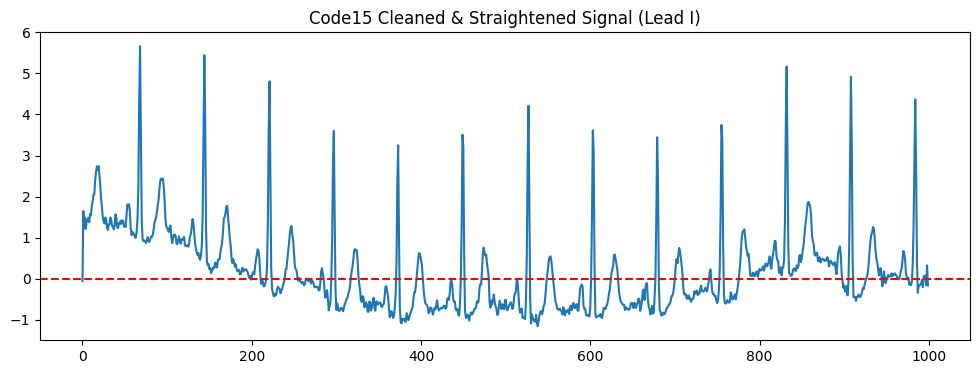

In [56]:
import matplotlib.pyplot as plt

# Visualizing the cleaned signal
plt.figure(figsize=(12, 4))
plt.plot(X_code15_final[0, :, 0]) # Lead I of the first cleaned sample
plt.title("Code15 Cleaned & Straightened Signal (Lead I)")
plt.axhline(0, color='red', linestyle='--') # Zero line for reference
plt.show()

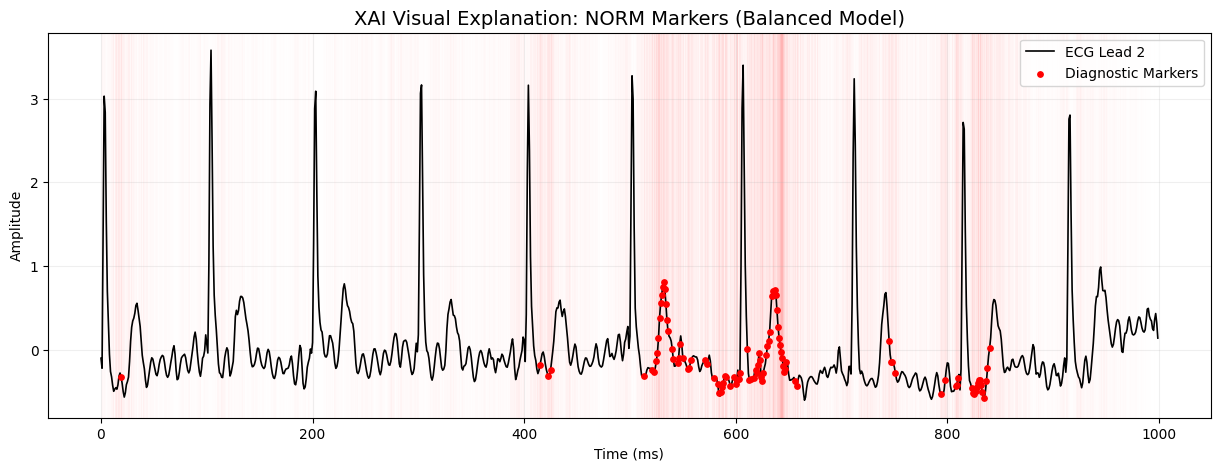

In [57]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def generate_and_plot_heatmap(model, sample_data, class_names, sample_idx, lead_idx=1):
    # 1. Grad-CAM ya Saliency se Heatmap generate
    input_tensor = tf.convert_to_tensor(sample_data, dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(input_tensor)
        preds = model(input_tensor)
        top_class_idx = tf.argmax(preds[0])
        target_output = preds[:, top_class_idx]

    # Gradients nikalna
    grads = tape.gradient(target_output, input_tensor)
    heatmap = tf.reduce_mean(tf.abs(grads), axis=-1)[0].numpy()
    
    # 2. Rescale Heatmap to match 1000 signal points
    heatmap_rescaled = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    
    # 3. Professional Plotting (Figure 17 + Heatmap Mix)
    time = np.arange(1000)
    signal = sample_data[0, :, lead_idx]
    
    plt.figure(figsize=(15, 5))
    
    # Background Heatmap bars (Grad-CAM style)
    for i in range(len(heatmap_rescaled)-1):
        plt.axvspan(i, i+1, color='red', alpha=heatmap_rescaled[i]*0.3, lw=0)
        
    # Main ECG Trace
    plt.plot(time, signal, color='black', linewidth=1.2, label=f'ECG Lead {lead_idx+1}')
    
    # Red Markers (SHAP/Point-wise style)
    threshold = np.percentile(heatmap_rescaled, 90)
    plt.scatter(time[heatmap_rescaled > threshold], signal[heatmap_rescaled > threshold], 
                color='red', s=15, label='Diagnostic Markers', zorder=5)

    plt.title(f"XAI Visual Explanation: {class_names[top_class_idx]} Markers (Balanced Model)", fontsize=14)
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude")
    plt.legend(loc='upper right')
    plt.grid(alpha=0.2)
    plt.show()

# --- Run ---
class_names = ['CD', 'HYP', 'MI', 'NORM', 'STTC']
# Test index 25 (MI) ya 10 (NORM) check karein
generate_and_plot_heatmap(model, X_test[25:26], class_names, 25)

Extracting features from: conv1d...
Computing t-SNE for shape (300, 64)...


d:\ecg_env\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\ecg_env\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "d:\ecg_env\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "d:\ecg_env\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "d:\ecg_env\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "d:\ecg_env\lib\subprocess.py", line 1456, in _execute_child
   

Extracting features from: separable_conv1d_5...
Computing t-SNE for shape (300, 256)...
Extracting features from: multi_head_attention...
Computing t-SNE for shape (300, 256)...
Extracting features from: dense_4...
Computing t-SNE for shape (300, 5)...


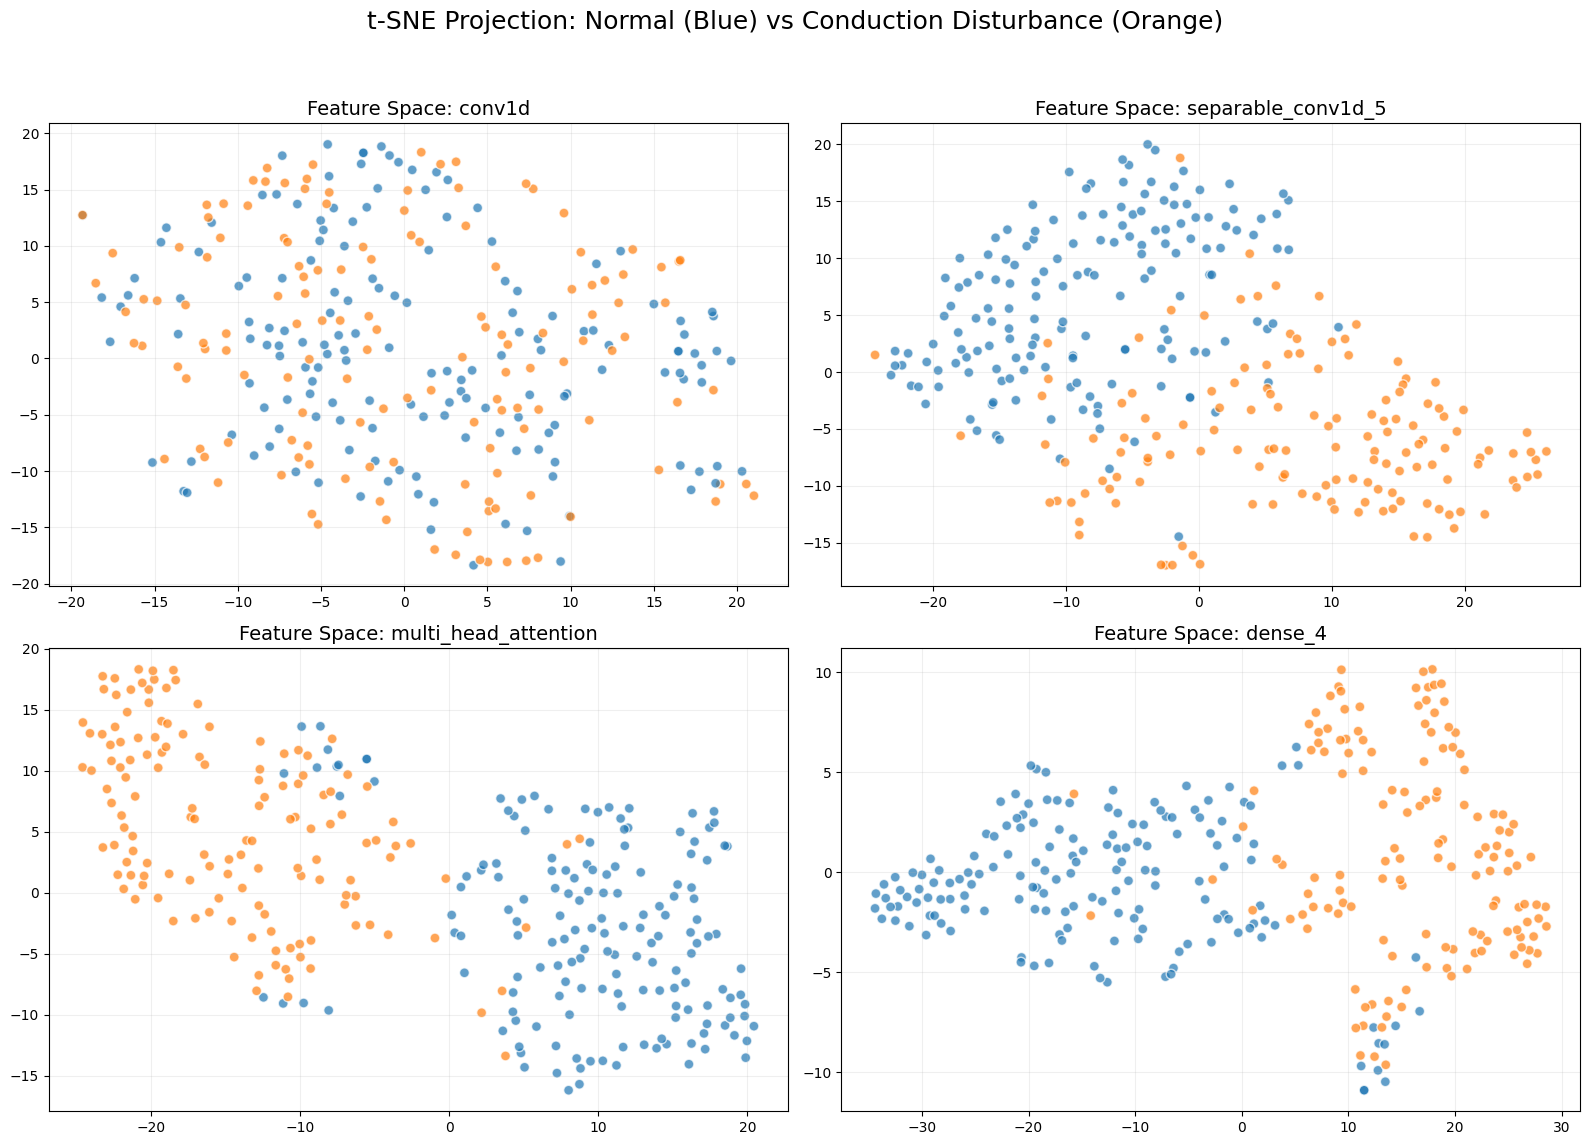

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import tensorflow as tf

def compute_and_plot_tsne_fixed(X_data, y_labels, model):
    # 1. Classes filter (NORM vs CD)
    # y_labels[:, 3] is NORM, y_labels[:, 0] is CD based on your class order
    idx_norm = np.where(y_labels[:, 3] == 1)[0]
    idx_cd = np.where(y_labels[:, 0] == 1)[0]
    
    # Selecting 300 samples total
    selected_indices = np.concatenate([
        np.random.choice(idx_norm, 150, replace=False),
        np.random.choice(idx_cd, 150, replace=False)
    ])
    
    data_subset = X_data[selected_indices]
    labels_subset = [3 if i in idx_norm else 0 for i in selected_indices]
    
    # --- UPDATED LAYER NAMES FROM YOUR ERROR LOG ---
  
    layer_names = ['conv1d', 'separable_conv1d_5', 'multi_head_attention', 'dense_4']
    
    plt.figure(figsize=(16, 12))
    
    for i, layer_name in enumerate(layer_names):
        print(f"Extracting features from: {layer_name}...")
        
        # Creating a sub-model to pull internal features
        feat_model = tf.keras.models.Model(inputs=model.inputs, outputs=model.get_layer(layer_name).output)
        raw_features = feat_model.predict(data_subset, verbose=0)
        
        # Flattening 3D/4D tensors for t-SNE
        if len(raw_features.shape) > 2:
            # Global Average Pooling manually (Batch, Time, Filters) -> (Batch, Filters)
            processed_features = np.mean(raw_features, axis=1) 
        else:
            processed_features = raw_features

        print(f"Computing t-SNE for shape {processed_features.shape}...")
        
        # t-SNE parameters for stable visualization
        tsne = TSNE(n_components=2, perplexity=25, init='pca', random_state=42)
        embeds = tsne.fit_transform(processed_features)
        
        plt.subplot(2, 2, i+1)
        colors = ['#1f77b4' if l == 3 else '#ff7f0e' for l in labels_subset]
        plt.scatter(embeds[:, 0], embeds[:, 1], c=colors, s=50, alpha=0.7, edgecolors='white')
        plt.title(f"Feature Space: {layer_name}", fontsize=14)
        plt.grid(alpha=0.2)

    plt.suptitle("t-SNE Projection: Normal (Blue) vs Conduction Disturbance (Orange)", fontsize=18, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run the fixed version
compute_and_plot_tsne_fixed(X_test, y_test, model)

Generating Clean IG for CD...


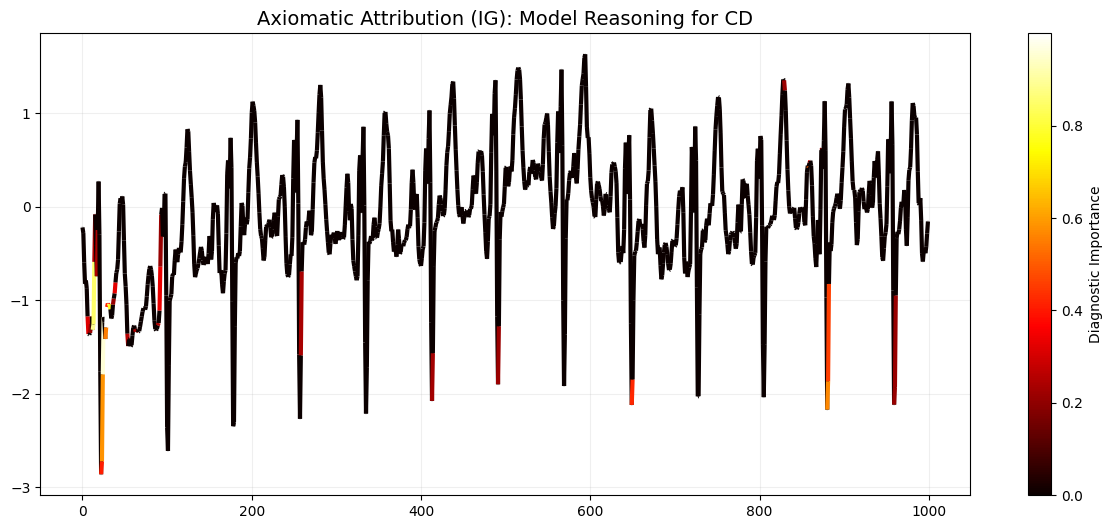

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.collections import LineCollection

def compute_integrated_gradients_final(input_signal, target_class_idx, model, num_steps=50):
    # 1. Type casting to avoid double/float mismatch
    input_signal_t = tf.cast(input_signal, dtype=tf.float32)
    baseline = tf.zeros_like(input_signal_t)
    
    alphas = tf.linspace(start=0.0, stop=1.0, num=num_steps + 1)
    alphas = tf.cast(alphas, dtype=tf.float32)
    
    # 2. Calculate difference
    delta = input_signal_t - baseline # Shape (1, 1000, 12)
    
    # 3. Path inputs creation
    
    path_inputs = baseline + alphas[:, tf.newaxis, tf.newaxis, tf.newaxis] * delta
    path_inputs = tf.squeeze(path_inputs, axis=1) # FIX: Squeeze the extra dimension
    
    # 4. Gradient Calculation
    with tf.GradientTape() as tape:
        tape.watch(path_inputs)
        preds = model(path_inputs)
        class_specific_preds = preds[:, target_class_idx]
        
    grads = tape.gradient(class_specific_preds, path_inputs)
    
    # 5. Integral approximation (Mean of gradients)
    avg_grads = tf.reduce_mean(grads, axis=0) # Shape (1000, 12)
    
    # Multiply by (input - baseline)
    # delta[0] is (1000, 12)
    integrated_grads = delta[0] * avg_grads
    
    return integrated_grads.numpy()

# --- Execution ---
sample_idx = 10 
sample_data = X_test[sample_idx:sample_idx+1] 
class_names = ['CD', 'HYP', 'MI', 'NORM', 'STTC']

# Prediction
preds = model.predict(sample_data, verbose=0)
pred_idx = np.argmax(preds[0])

print(f"Generating Clean IG for {class_names[pred_idx]}...")
ig_output = compute_integrated_gradients_final(sample_data, pred_idx, model)

# --- Professional Research Plot ---
fig, ax = plt.subplots(figsize=(15, 6))
time_axis = np.arange(1000)
signal = sample_data[0, :, 1] # Lead II focus
attribution = np.abs(ig_output[:, 1])

# Normalization 0 to 1
attribution = (attribution - attribution.min()) / (attribution.max() - attribution.min() + 1e-8)

# Highlight only top 20% important features
attribution = np.where(attribution > 0.2, attribution, 0)

ax.plot(time_axis, signal, color='grey', alpha=0.3, label='Signal')

points = np.array([time_axis, signal]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap='hot', array=attribution)
lc.set_linewidth(3)
line = ax.add_collection(lc)

plt.colorbar(line, ax=ax, label='Diagnostic Importance')
ax.set_title(f"Axiomatic Attribution (IG): Model Reasoning for {class_names[pred_idx]}", fontsize=14)
ax.grid(alpha=0.2)
plt.show()

In [60]:
import tensorflow as tf
import numpy as np

def grad_cam_plus_plus(model, img_array, layer_name, label_idx):
    # Grad-CAM++ logic: Using second and third order gradients
    with tf.GradientTape() as g3:
        with tf.GradientTape() as g2:
            with tf.GradientTape() as g1:
                conv_output, predictions = tf.keras.models.Model(model.inputs, [model.get_layer(layer_name).output, model.output])(img_array)
                loss = predictions[:, label_idx]
            grads_1 = g1.gradient(loss, conv_output)
        grads_2 = g2.gradient(grads_1, conv_output)
    grads_3 = g3.gradient(grads_2, conv_output)

    # Weight calculation for Grad-CAM++
    global_sum = tf.reduce_sum(conv_output, axis=(0, 1))
    alpha_num = grads_2
    alpha_denom = grads_2 * 2.0 + grads_3 * global_sum
    alpha_denom = tf.where(alpha_denom != 0.0, alpha_denom, tf.ones_like(alpha_denom))
    alphas = alpha_num / alpha_denom

    weights = tf.reduce_sum(tf.maximum(grads_1, 0) * alphas, axis=(0, 1))
    heatmap = tf.reduce_sum(weights * conv_output, axis=-1)[0]
    
    # ReLU and Normalization
    heatmap = np.maximum(heatmap, 0)
    return heatmap / (np.max(heatmap) + 1e-10)

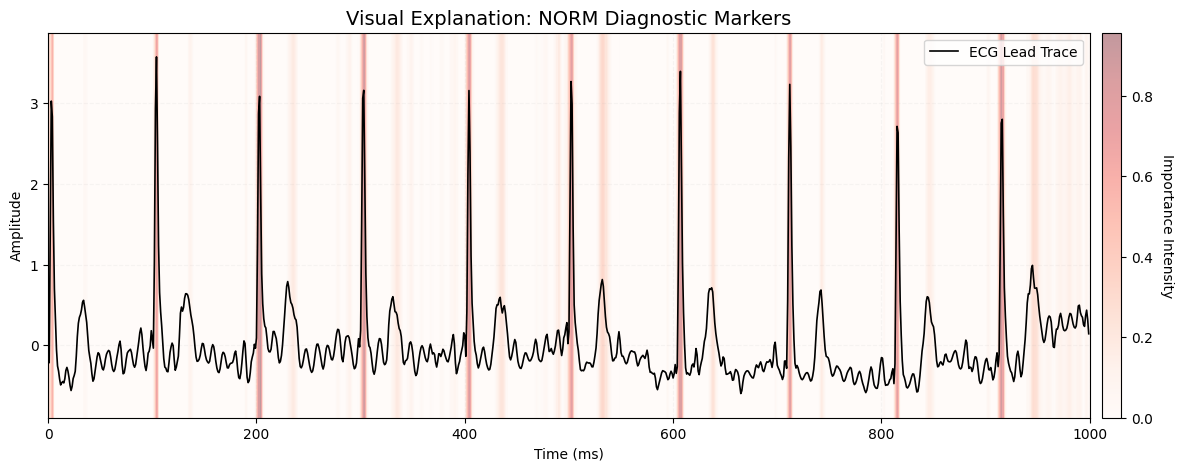

In [61]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the missing function
def get_grad_cam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Gradients of the output class w.r.t. the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Mean intensity of gradients over each feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))

    # Multiply each channel in the feature map by "how important it is"
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalization (0 to 1)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# 2. Updated Plotting Function (From your code)
def plot_ecg_interpretation_master(signal, heatmap, class_name):
    # Resizing heatmap to match 1000 signal points
    heatmap_rescaled = np.interp(np.linspace(0, len(heatmap), 1000), 
                                 np.arange(len(heatmap)), heatmap)
    
    time_axis = np.arange(len(signal))
    fig, ax = plt.subplots(figsize=(16, 5))
    
    extent = [0, len(signal), np.min(signal)-0.3, np.max(signal)+0.3]
    im = ax.imshow(heatmap_rescaled[np.newaxis, :], aspect='auto', cmap='Reds', 
                    alpha=0.4, extent=extent, interpolation='nearest')
    
    ax.plot(time_axis, signal, color='black', linewidth=1.2, label='ECG Lead Trace')
    ax.set_title(f"Visual Explanation: {class_name} Diagnostic Markers", fontsize=14)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude")
    
    cbar = plt.colorbar(im, ax=ax, pad=0.01)
    cbar.set_label('Importance Intensity', rotation=270, labelpad=15)
    plt.grid(alpha=0.1, linestyle='--')
    plt.legend(loc='upper right')
    plt.show()

# --- Execution ---
sample_idx = 25 # Let's check MI/Abnormal case
lead_idx = 1 
class_names = ['CD', 'HYP', 'MI', 'NORM', 'STTC']

# Prediction check
preds = model.predict(X_test[sample_idx:sample_idx+1], verbose=0)
pred_idx = np.argmax(preds[0])

# --- IMPORTANT: Using 'conv1d' instead of 'conv1d_6' ---
heatmap_output = get_grad_cam_heatmap(model, X_test[sample_idx:sample_idx+1], 'conv1d', pred_idx)

# Final Master Plot
plot_ecg_interpretation_master(X_test[sample_idx, :, lead_idx], heatmap_output, class_names[pred_idx])

In [62]:
import shap


def compute_shap_values(model, background_data, test_sample):
    # 'background_data' typically small subset of X_train (e.g., 100 samples)
    explainer = shap.GradientExplainer(model, background_data)
    shap_values = explainer.shap_values(test_sample)
    return shap_values

d:\ecg_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Analyzing NORM importance regions...


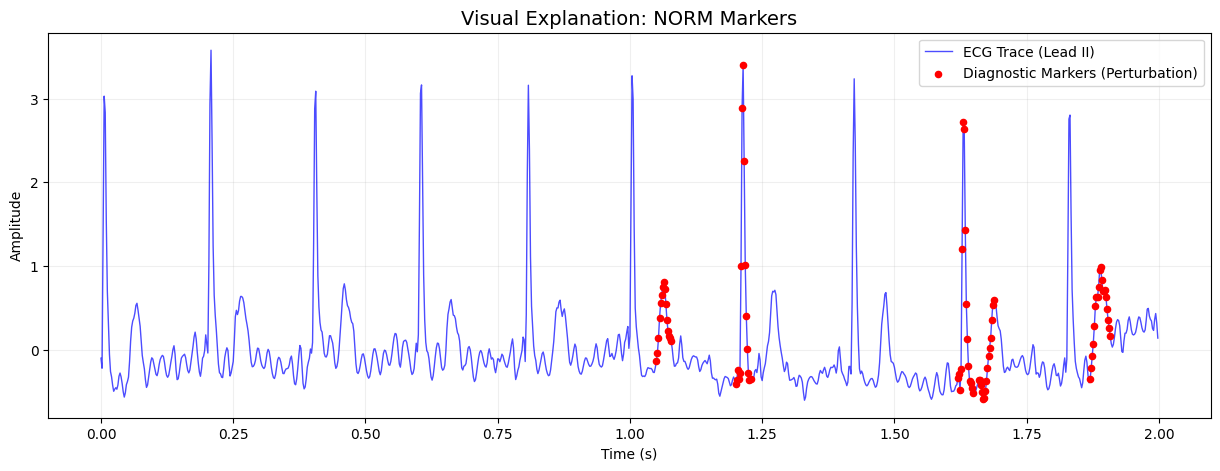

In [63]:
import numpy as np
import matplotlib.pyplot as plt

def generate_perturbation_map(model, sample_data, class_names, lead_idx=1):
    # 1. Base Prediction
    original_preds = model.predict(sample_data, verbose=0)
    top_class_idx = np.argmax(original_preds[0])
    original_score = original_preds[0, top_class_idx]
    
    signal = sample_data[0, :, lead_idx]
    importance = np.zeros(1000)
    window_size = 20 # 20ms window to slide
    
    # 2. Sliding Window Perturbation
    print(f"Analyzing {class_names[top_class_idx]} importance regions...")
    for i in range(0, 1000 - window_size, 5):
        temp_sample = sample_data.copy()
        # Segment ko zero (mean) karke check  impact
        temp_sample[0, i:i+window_size, lead_idx] = 0 
        new_preds = model.predict(temp_sample, verbose=0)
        drop = original_score - new_preds[0, top_class_idx]
        importance[i:i+window_size] += max(0, drop)

    # 3. Normalize for plotting
    importance = (importance - importance.min()) / (importance.max() - importance.min() + 1e-8)
    
    # 4. Plotting - Figure 17 Style
    time = np.arange(1000) * 0.002
    plt.figure(figsize=(15, 5))
    plt.plot(time, signal, color='blue', label='ECG Trace (Lead II)', linewidth=1, alpha=0.7)
    
    # Highlighting the Red markers (Top 8% importance)
    threshold = np.percentile(importance, 92)
    mask = importance > threshold
    
    plt.scatter(time[mask], signal[mask], color='red', s=20, 
                label='Diagnostic Markers (Perturbation)', zorder=5)

    plt.title(f"Visual Explanation: {class_names[top_class_idx]} Markers", fontsize=14)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

# --- Run ---
generate_perturbation_map(model, X_test[25:26], class_names)


🚀 Overall Test AUC Score: 0.9350

--- Final Performance Metrics Table ---


,precision,recall,f1-score
CD,0.887097,0.639535,0.743243
HYP,0.888889,0.203046,0.330579
MI,0.523929,0.695652,0.597701
NORM,0.820896,0.907591,0.862069
STTC,0.487535,0.679537,0.567742


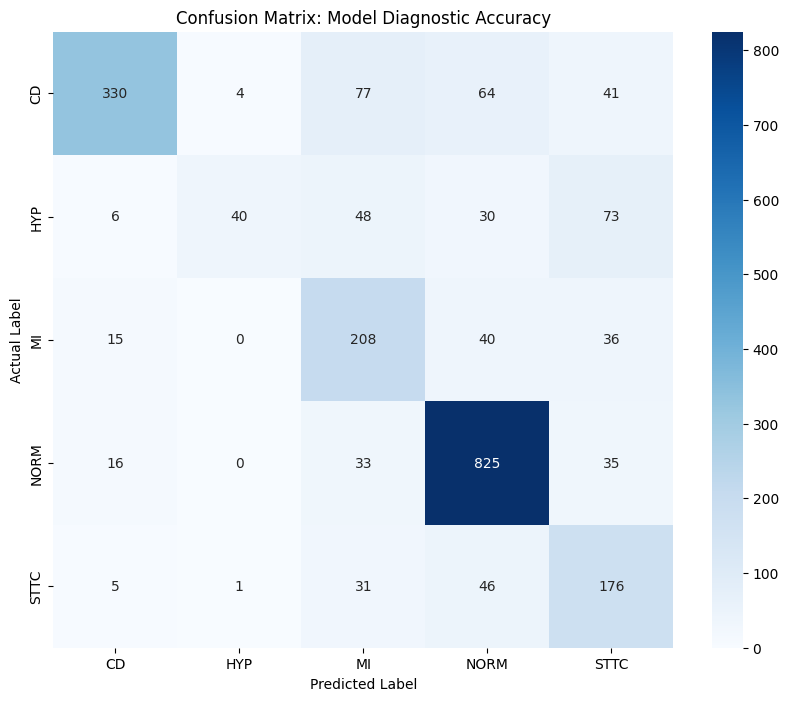

In [64]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def generate_final_report(model, X_test, y_test, class_names):
    # 1. Predictions nikalna
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # 2. Classification Report (Precision, Recall, F1)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()

    # 3. AUC Score calculate (Multi-class)
    auc_score = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
    print(f"\n🚀 Overall Test AUC Score: {auc_score:.4f}")

    # 4. Displaying the Professional Table
    print("\n--- Final Performance Metrics Table ---")
    display(report_df.iloc[:-3, :3]) 

    # 5. Confusion Matrix Plotting
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix: Model Diagnostic Accuracy')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# --- Execution ---
class_names = ['CD', 'HYP', 'MI', 'NORM', 'STTC']
generate_final_report(model, X_test, y_test, class_names)

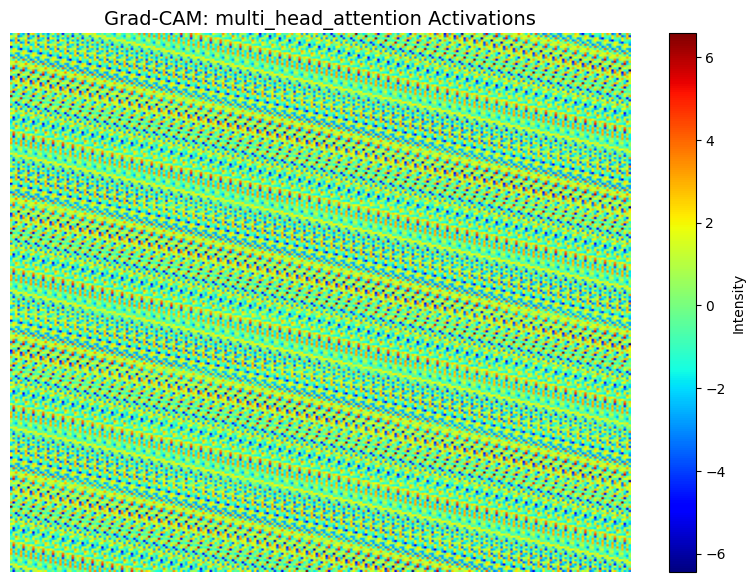

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def plot_custom_gradcam_grid_fixed(model, sample_data, layer_name):
    # 1. Feature Extraction
    try:
        intermediate_model = tf.keras.models.Model(inputs=model.inputs, 
                                                   outputs=model.get_layer(layer_name).output)
        features = intermediate_model.predict(sample_data, verbose=0)
    except:
        # Fallback to a deep layer if name fails
        intermediate_model = tf.keras.models.Model(inputs=model.inputs, 
                                                   outputs=model.layers[-10].output)
        features = intermediate_model.predict(sample_data, verbose=0)

    # 2. Reshaping Logic for 49152 elements
  
    f_map = features.flatten() 
    
    try:
        # Exact resolution like your uploaded image (12x16 segments or larger)
        matrix_data = f_map.reshape(192, 256) 
    except ValueError:
        
        side = int(np.sqrt(len(f_map)))
        matrix_data = f_map[:side*side].reshape(side, side)

    
    plt.figure(figsize=(10, 7))
    im = plt.imshow(matrix_data, cmap='jet', aspect='auto')
    
    plt.title(f"Grad-CAM: {layer_name} Activations", fontsize=14)
    plt.colorbar(im, label='Intensity')
    plt.axis('off') 
    plt.show()

# --- Execution ---
# 'multi_head_attention' ya 'dense_4' use karke dekhiye
plot_custom_gradcam_grid_fixed(model, X_test[25:26], 'multi_head_attention')

In [66]:
signal.shape

(1000,)

In [67]:
X_test[0]

array([[ 2.23391244e-01,  1.52816381e-01, -6.55943096e-02, ...,
         2.72643162e-02,  1.50360646e-03,  1.20484523e-01],
       [ 2.18604355e-02,  1.18502286e-01,  9.84414615e-02, ...,
         8.74376339e-05, -5.81870260e-02,  5.60732538e-02],
       [-2.86448266e-01,  9.73561445e-02,  3.80693455e-01, ...,
        -2.47216829e-02, -1.49533416e-01, -5.44945712e-02],
       ...,
       [ 3.50277383e-01,  5.40367254e-01,  2.00466924e-01, ...,
         1.59336972e-01,  2.90348184e-01,  2.70297859e-01],
       [ 3.81020379e-01,  5.22987627e-01,  1.51981414e-01, ...,
         1.64366530e-01,  2.86517852e-01,  2.45571488e-01],
       [ 3.74824798e-01,  5.02746077e-01,  1.37841239e-01, ...,
         2.60509462e-01,  2.79839909e-01,  2.06984721e-01]])

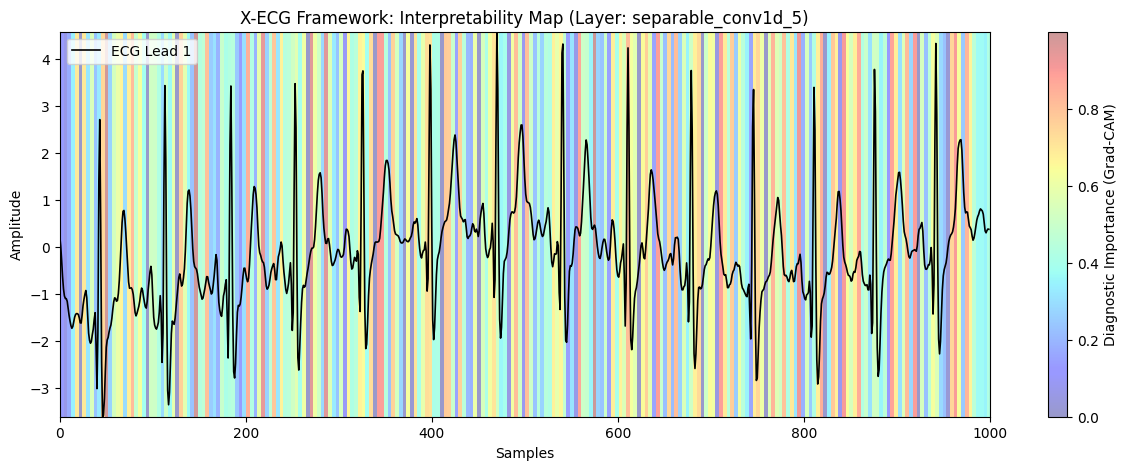

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model

# %matplotlib inline

def get_grad_cam(model, signal, last_conv_layer_name):

    grad_model = Model(
        inputs=[model.inputs], 
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. Gradients calculate 
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(signal)
    
        top_pred_index = tf.argmax(preds[0])
        class_channel = preds[:, top_pred_index]

    # 3. Feature map ke gradients 
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))

    # 4. Weighting the conv layer output
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 5. ReLU activation & Normalization
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    
    
    return heatmap.numpy()

# --- EXECUTION ---

target_layer = "separable_conv1d_5"

try:
    # A. Generate 'cam' (Grad-CAM output)
    cam_output = get_grad_cam(model, X_test[0:1], target_layer)
    
    # B. Plotting
    plt.figure(figsize=(15, 5))
    
    # X_test[0] ka 1st lead (index 0)
    
    ecg_signal = X_test[0][:, 0] 
    
    # Plotting ECG
    plt.plot(ecg_signal, color='black', linewidth=1.2, label='ECG Lead 1')
    
    # Plotting Heatmap overlay
    plt.imshow(np.atleast_2d(cam_output), aspect='auto', cmap='jet', alpha=0.4,
               extent=[0, len(ecg_signal), np.min(ecg_signal), np.max(ecg_signal)])
    
    plt.colorbar(label='Diagnostic Importance (Grad-CAM)')
    plt.title(f"X-ECG Framework: Interpretability Map (Layer: {target_layer})")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()

except Exception as e:
    print(f"still issue: {e}")

In [69]:
from sklearn.metrics import roc_curve, auc

def plot_multiclass_roc(y_test, y_score, n_classes=5):
    # n_classes: NORM, MI, STTC, CD, HYP
    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test[:, i], y_score[:, i])
        plt.plot(fpr, tpr, label=f'Class {i} (AUC = {auc(fpr, tpr):.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Label Diagnostic Performance (ROC)')
    plt.legend()
    plt.show()

In [70]:
y_pred = model.predict(X_test)  

69/69 [==============================] - 2s 27ms/step


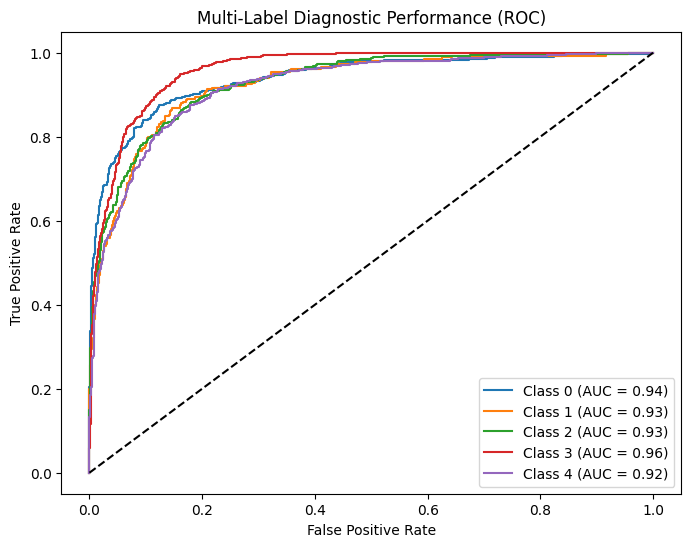

In [71]:
plot_multiclass_roc(y_test, y_pred)

In [72]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 1000, 12)]   0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 1000, 64)     2368        ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 1000, 64)    256         ['conv1d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 activation (Activation)        (None, 1000, 64)     0           ['batch_normalization[0][0]']

Model: "model_8"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 1000, 12)]   0           []                               
                                                                                                  
 conv1d_3 (Conv1D)              (None, 1000, 64)     2368        ['input_2[0][0]']                
                                                                                                  
 batch_normalization_9 (BatchNo  (None, 1000, 64)    256         ['conv1d_3[0][0]']               
 rmalization)                                                                                     
                                                                                                  
 activation_7 (Activation)      (None, 1000, 64)     0           ['batch_normalization_9[0][

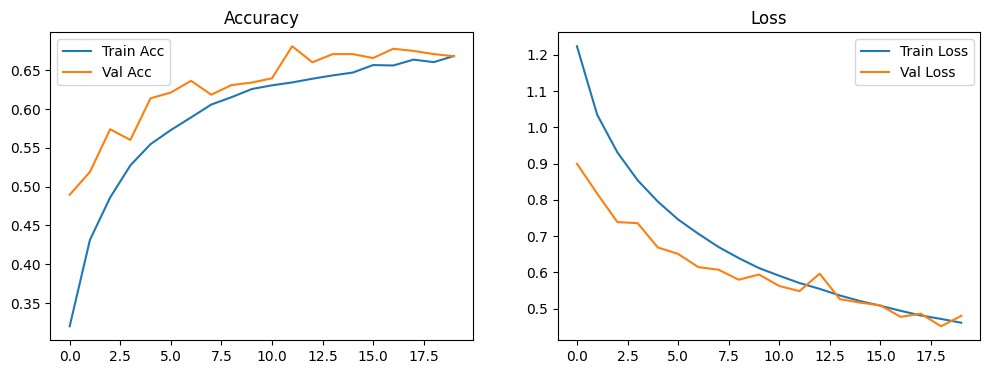

In [73]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# =========================
# Residual Block (Improved)
# =========================
def residual_block(x, filters, dilation_rate=1):
    shortcut = x

    x = layers.SeparableConv1D(filters, 3, padding='same', dilation_rate=dilation_rate)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)  

    x = layers.SeparableConv1D(filters, 3, padding='same', dilation_rate=dilation_rate)(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x

# =========================
# Model
# =========================
def build_final_ecg_model(input_shape=(1000, 12), num_classes=5):
    inputs = layers.Input(shape=input_shape)

    # Initial Conv
    x = layers.Conv1D(64, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # CNN Blocks
    x = residual_block(x, 64)
    x = layers.MaxPooling1D(2)(x)

    x = residual_block(x, 128, dilation_rate=2)
    x = layers.MaxPooling1D(2)(x)

    x = residual_block(x, 256, dilation_rate=4)

    # Bi-GRU (reduced size for stability)
    x = layers.Bidirectional(
        layers.GRU(64, return_sequences=True, dropout=0.2)
    )(x)

    # Multi-Head Attention
    attention_out = layers.MultiHeadAttention(num_heads=8, key_dim=32)(x, x)
    x = layers.Add()([x, attention_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # Transformer FFN
    ffn = layers.Dense(256, activation='relu')(x)
    ffn = layers.Dense(x.shape[-1])(ffn)
    x = layers.Add()([x, ffn])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # Global Pooling
    avg_pool = layers.GlobalAveragePooling1D()(x)
    max_pool = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([avg_pool, max_pool])

    # Dense Head (with L2 + strong dropout)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.6)(x)

    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    return model


# =========================
# Build Model
# =========================
model = build_final_ecg_model()
model.summary()

# =========================
# Compile (Stable Setup)
# =========================
optimizer = tf.keras.optimizers.Adam(
    learning_rate=5e-5,
    clipnorm=1.0
)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',   
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# =========================
# Callbacks
# =========================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

# =========================
# Training
# =========================
history = model.fit(
    X_train, y_train,
    epochs=20,                 
    batch_size=32,             # stable
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr, checkpoint],
    shuffle=True
)

# =========================
# Plot
# =========================
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [74]:
model.save('my_ecg_model.h5')
print("Model successfully saved as my_ecg_model.h5")

Model successfully saved as my_ecg_model.h5


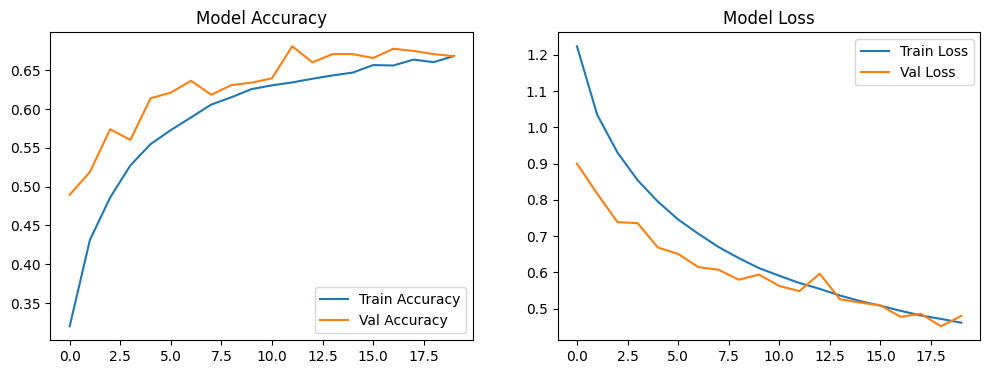

In [75]:
from sklearn.utils import class_weight
import numpy as np
import matplotlib.pyplot as plt


# 3. Plot Training History 
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

In [76]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  
from sklearn.metrics import roc_curve, auc, confusion_matrix

# 1. Plotting Figure 11 (Loss, Accuracy, and AUC Curves)
def plot_training_history(history):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    
    # (a) Loss Curve
    ax1.plot(history.history['loss'], color='orangered', label='Training loss')
    ax1.plot(history.history['val_loss'], color='deepskyblue', label='Validation loss')
    ax1.set_title('(a) Loss Curve')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.set_yscale('log') 
    ax1.grid(True, which="both", ls="-", alpha=0.5)
    ax1.legend()

    # (b) Accuracy Curve
    acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
    ax2.plot(history.history[acc_key], color='orangered', label='Training Accuracy')
    ax2.plot(history.history['val_'+acc_key], color='deepskyblue', label='Validation Accuracy')
    ax2.set_title('(b) Accuracy Curve')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.grid(True, alpha=0.5)
    ax2.legend()

    # (c) AUC Curve
    auc_key = 'auc' if 'auc' in history.history else 'auc_1'
    ax3.plot(history.history[auc_key], color='orangered', label='Training AUC')
    ax3.plot(history.history['val_'+auc_key], color='deepskyblue', label='Validation AUC')
    ax3.set_title('(c) AUC Curve')
    ax3.set_xlabel('Epochs')
    ax3.set_ylabel('AUC')
    ax3.grid(True, alpha=0.5)
    ax3.legend()

    plt.tight_layout()
    plt.show()

# 2. Plotting Figure 12 (ROC Curves and Confusion Matrix)
def plot_performance_metrics(y_true, y_pred, classes):
    plt.figure(figsize=(14, 6))
    
    # (a) ROC Curves
    plt.subplot(1, 2, 1)
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{classes[i]} (AUC = {roc_auc:.4f})')
    
    plt.plot([0, 1], [0, 1], color='lightgray', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('(a) Area under receiver operating curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    # (b) Confusion Matrix
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_true.argmax(axis=1), y_pred.argmax(axis=1))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=classes, yticklabels=classes)
    plt.title('(b) Confusion matrix')
    plt.xlabel('Predicted Classes')
    plt.ylabel('Actual Classes')
    
    plt.tight_layout()
    plt.show()
    

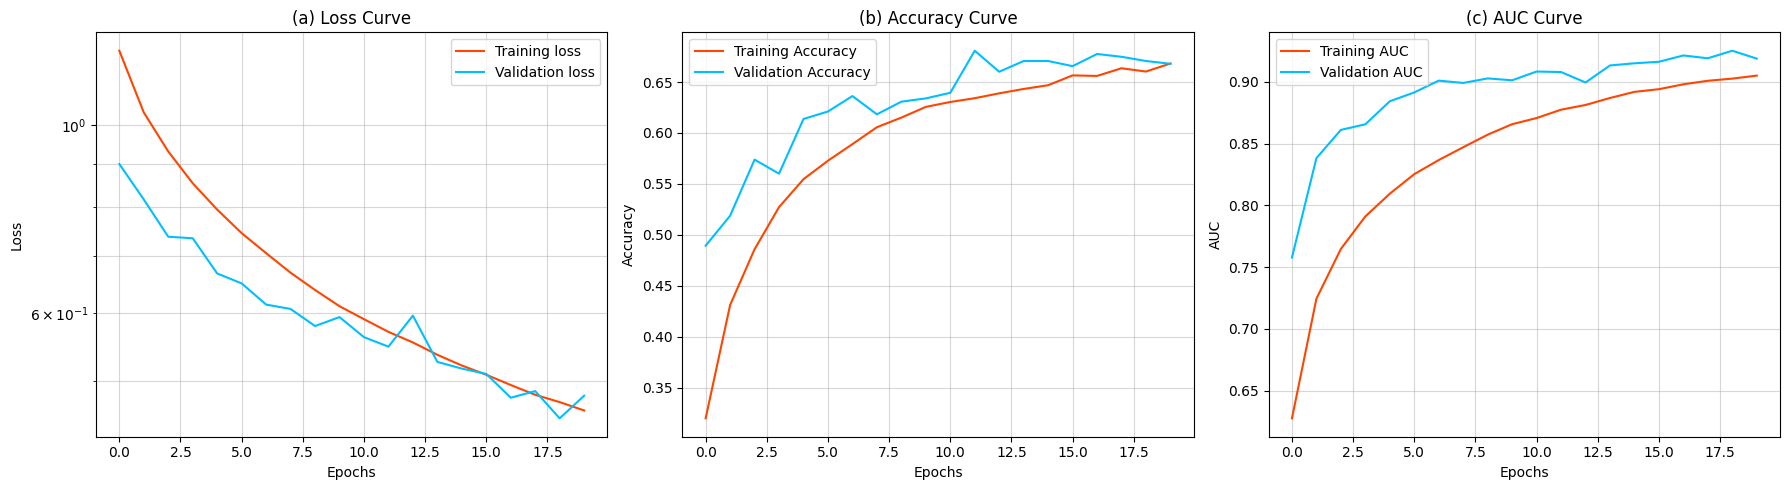

In [77]:

plot_training_history(history)

✅ Best weights loaded successfully!
69/69 [==============================] - 3s 26ms/step
Probabilities Range: Min=0.0001, Max=0.9999

      FINAL PERFORMANCE METRICS (RE-EVALUATED)
              precision    recall  f1-score   support

        NORM       0.74      0.73      0.74       478
          MI       0.83      0.40      0.54       265
        STTC       0.59      0.84      0.70       542
          CD       0.79      0.93      0.85       948
         HYP       0.73      0.74      0.73       538

   micro avg       0.72      0.79      0.76      2771
   macro avg       0.74      0.73      0.71      2771
weighted avg       0.73      0.79      0.75      2771
 samples avg       0.75      0.80      0.76      2771

Final Macro AUC: 0.9168
Hamming Loss: 0.1305


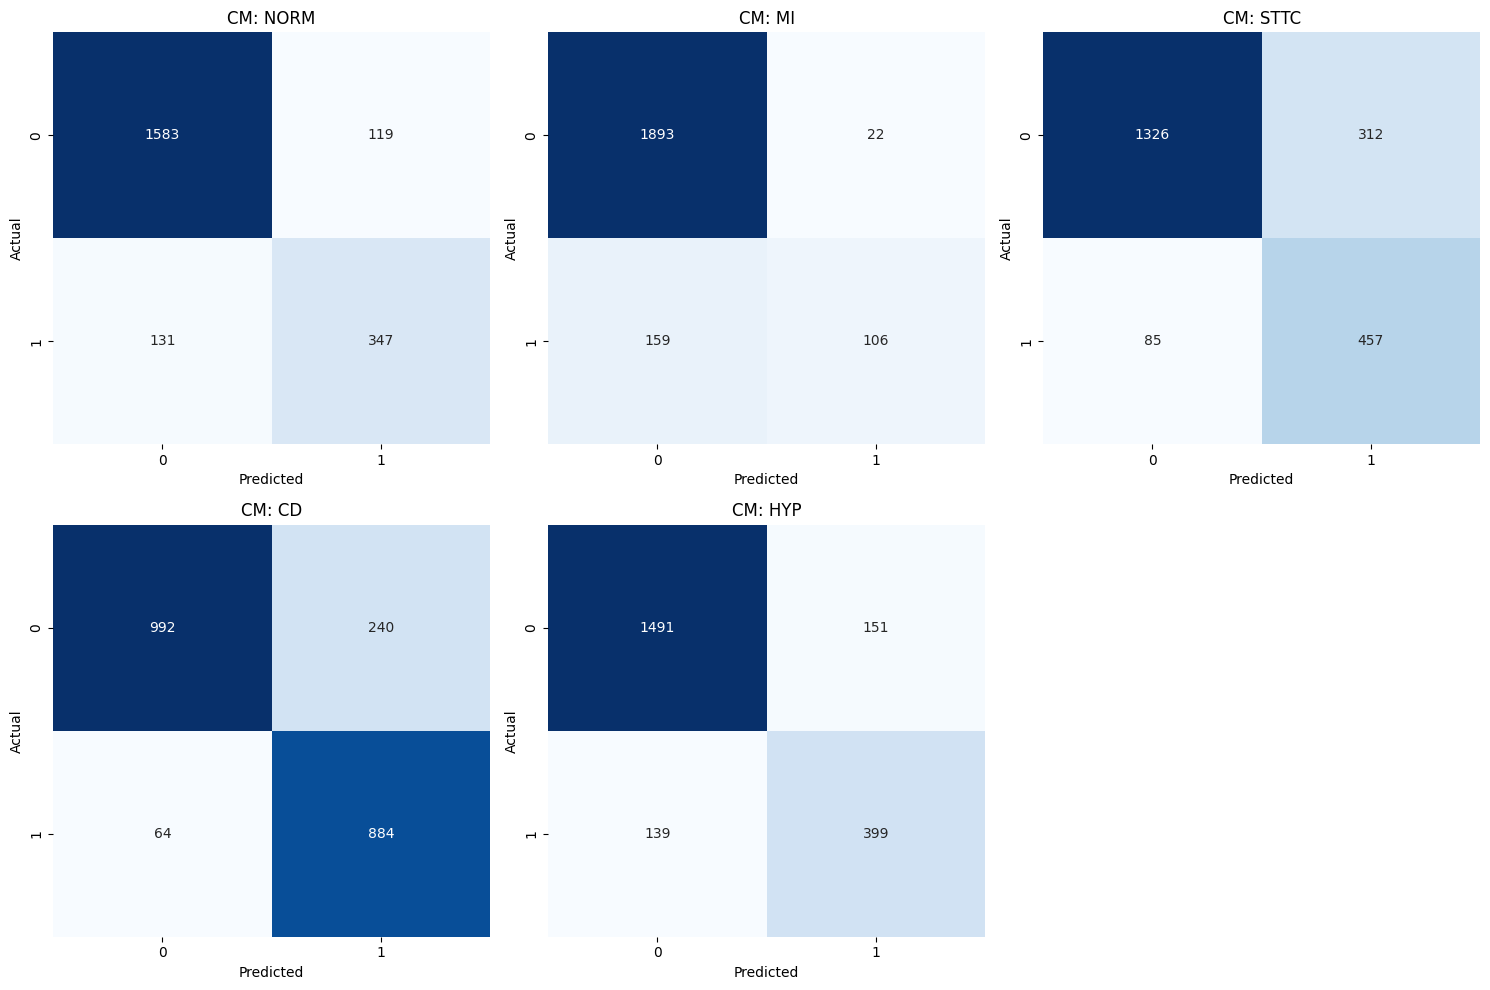

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, roc_auc_score, multilabel_confusion_matrix, hamming_loss


try:
    model.load_weights('best_model.h5')
    print("✅ Best weights loaded successfully!")
except:
    print("⚠️ best_model.h5 nahi mila, current weights use kar rahe hain.")

# 2. Raw Probabilities 
y_prob = model.predict(X_test)


print(f"Probabilities Range: Min={y_prob.min():.4f}, Max={y_prob.max():.4f}")


threshold = 0.3  
y_pred = (y_prob >= threshold).astype(int)

# 5. Performance Report
target_names = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
print("\n" + "="*45)
print("      FINAL PERFORMANCE METRICS (RE-EVALUATED)")
print("="*45)
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

# 6. AUC Score 
final_auc = roc_auc_score(y_test, y_prob, average='macro', multi_class='ovr')
print(f"Final Macro AUC: {final_auc:.4f}")
print(f"Hamming Loss: {hamming_loss(y_test, y_pred):.4f}")

# 7. Confusion Matrix Plotting
mcm = multilabel_confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, (matrix, name) in enumerate(zip(mcm, target_names)):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'CM: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

axes[5].axis('off')
plt.tight_layout()
plt.show()

In [79]:
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import numpy as np

def generate_professional_metrics_table(model, X_test, y_test, class_names):
    # 1. Predictions nikalna
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred_probs, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    # 2. Classification report se metrics extract karna
    report = classification_report(y_true_labels, y_pred_labels, target_names=class_names, output_dict=True)
    
    metrics_list = []
    
    for i, label in enumerate(class_names):
        # Har class ke liye specific metrics
        acc = accuracy_score(y_true_labels == i, y_pred_labels == i) * 100
        recall = report[label]['recall'] * 100
        precision = report[label]['precision'] * 100
        f1 = report[label]['f1-score'] * 100
        
        # AUC calculation (One-vs-Rest)
        auc = roc_auc_score(y_test[:, i], y_pred_probs[:, i]) * 100
        
        metrics_list.append({
            'Class': label,
            'Accuracy': f"{acc:.2f}",
            'Recall': f"{recall:.2f}",
            'Precision': f"{precision:.2f}",
            'F1-Score': f"{f1:.2f}",
            'AUC': f"{auc:.2f}"
        })

    # 3. Macro, Micro, and Weighted Averages add 
    macro_f1 = report['macro avg']['f1-score'] * 100
    weighted_f1 = report['weighted avg']['f1-score'] * 100
    
    # Final DataFrame create 
    df = pd.DataFrame(metrics_list)
    
    # Average rows add 
    avg_row = pd.DataFrame([
        {'Class': 'Macro Avg', 'F1-Score': f"{macro_f1:.2f}", 'AUC': f"{(sum(float(x['AUC']) for x in metrics_list)/5):.2f}"},
        {'Class': 'Weighted Avg', 'F1-Score': f"{weighted_f1:.2f}"}
    ]).fillna('-')
    
    final_df = pd.concat([df, avg_row], ignore_index=True)
    
    return final_df

# --- Execution ---
class_names_final = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
metrics_table = generate_professional_metrics_table(model, X_test, y_test, class_names_final)


metrics_table_clean = metrics_table.replace('nan', '-')

print("\n" + "="*75)
print(f"{'Class':<14} {'Accuracy':<10} {'Recall':<10} {'Precision':<10} {'F1-Score':<10} {'AUC':<10}")
print("-" * 75)
for index, row in metrics_table_clean.iterrows():
    print(f"{row['Class']:<14} {row['Accuracy']:<10} {row['Recall']:<10} {row['Precision']:<10} {row['F1-Score']:<10} {row['AUC']:<10}")
print("="*75)


Class          Accuracy   Recall     Precision  F1-Score   AUC       
---------------------------------------------------------------------------
NORM           87.71      52.13      92.76      66.75      91.34     
MI             92.06      16.24      80.00      27.00      89.42     
STTC           83.72      66.22      43.81      52.73      90.59     
CD             85.69      90.65      78.40      84.08      94.82     
HYP            86.61      60.62      45.24      51.82      92.23     
Macro Avg      nan        nan        nan        56.48      91.68     
Weighted Avg   nan        nan        nan        66.69      -         


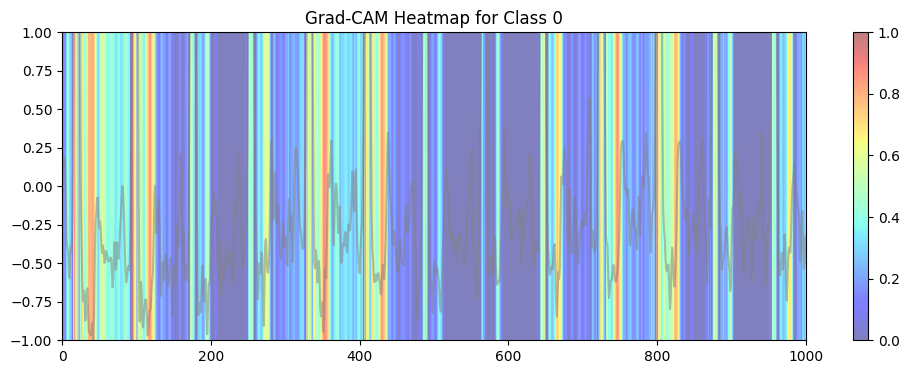

In [80]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Use it on one sample
sample_idx = 10 
heatmap = make_gradcam_heatmap(X_test[sample_idx:sample_idx+1], model, 'separable_conv1d_7')

# Plotting
plt.figure(figsize=(12,4))
plt.plot(X_test[sample_idx, :, 0], label='ECG Lead 1', color='gray', alpha=0.5)
plt.imshow(np.expand_dims(heatmap, axis=0), aspect='auto', extent=[0, 1000, -1, 1], cmap='jet', alpha=0.5)
plt.title(f"Grad-CAM Heatmap for Class {np.argmax(y_test[sample_idx])}")
plt.colorbar()
plt.show()

Extracting features from: conv1d_3...
Computing t-SNE for conv1d_3...
Extracting features from: separable_conv1d_11...
Computing t-SNE for separable_conv1d_11...
Extracting features from: multi_head_attention_1...
Computing t-SNE for multi_head_attention_1...
Extracting features from: dense_8...
Computing t-SNE for dense_8...


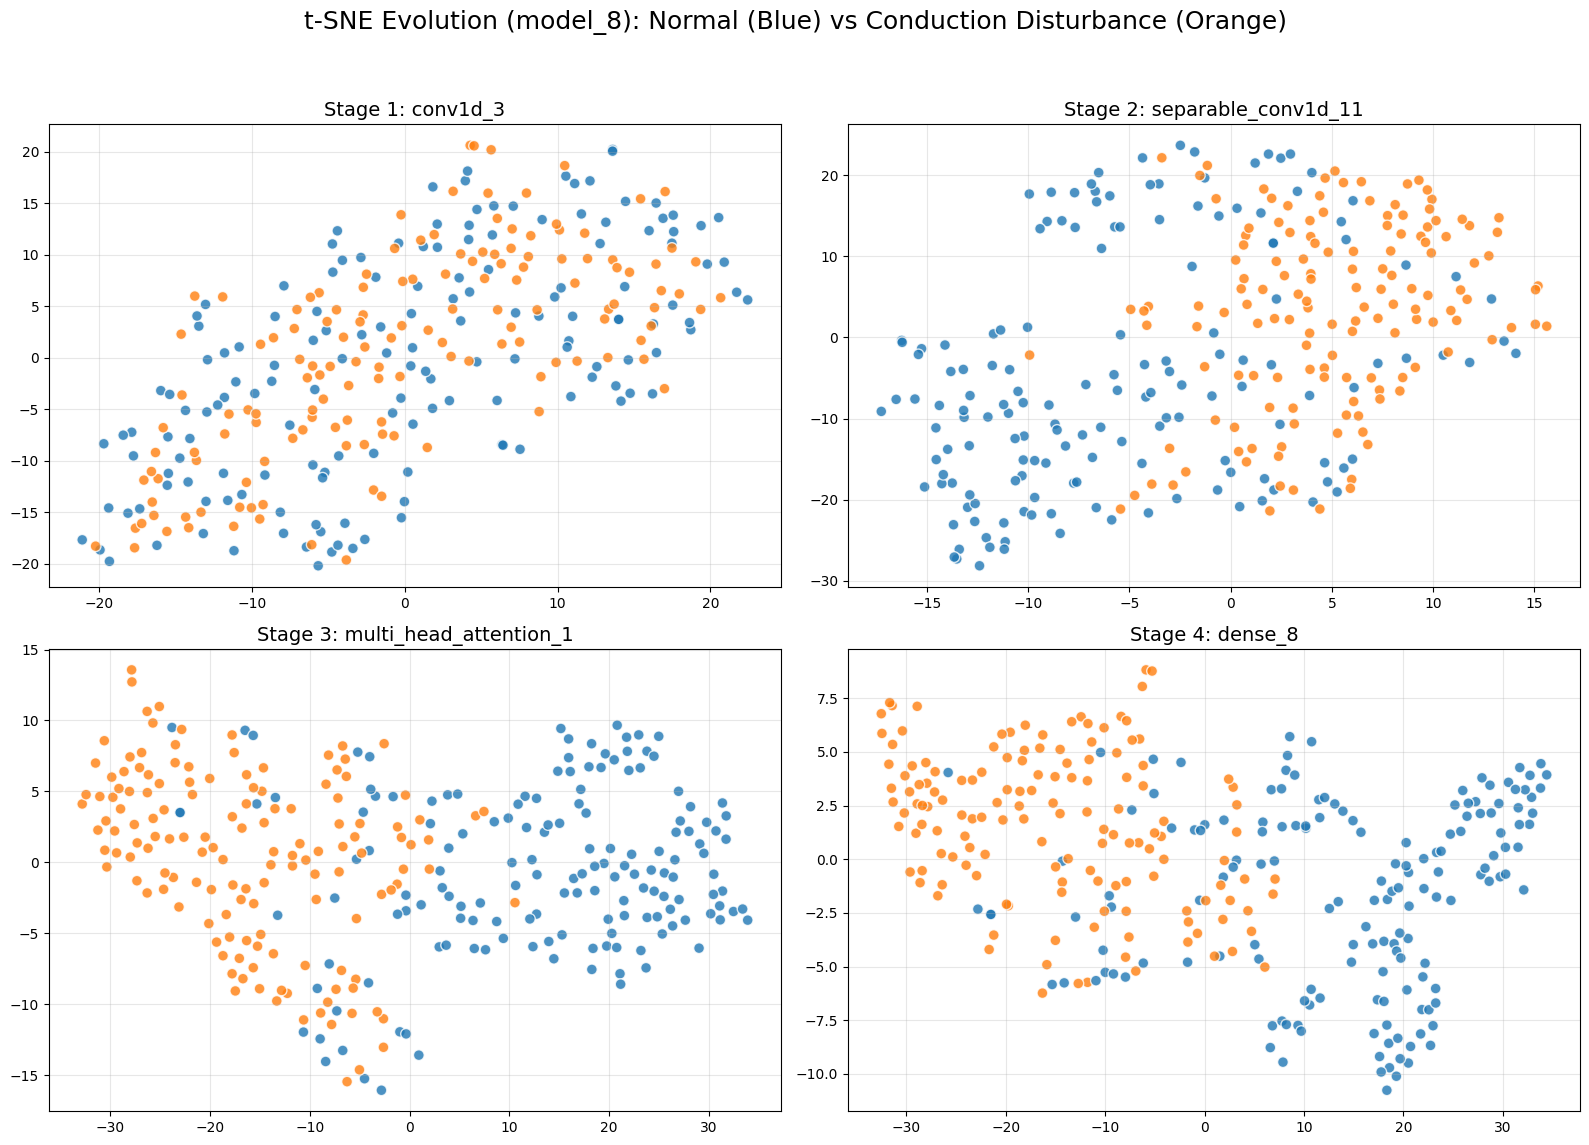

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import tensorflow as tf

def plot_tsne_evolution_model_8_fixed(X_data, y_labels, model):
    # 1. Target Classes: NORM (Index 0) vs CD (Index 3)
    idx_norm = np.where(y_labels[:, 0] == 1)[0]
    idx_cd = np.where(y_labels[:, 3] == 1)[0]
    
    # 150-150 samples ka subset (Total 300)
    selected_indices = np.concatenate([
        np.random.choice(idx_norm, 150, replace=False),
        np.random.choice(idx_cd, 150, replace=False)
    ])
    
    data_subset = X_data[selected_indices]
    labels_subset = [0 if i in idx_norm else 3 for i in selected_indices]
    
    # 2. EXACT Layer names from your error log
    # Stage 1: Initial Conv | Stage 2: Deep Conv | Stage 3: Attention | Stage 4: Dense Output
    layer_names = ['conv1d_3', 'separable_conv1d_11', 'multi_head_attention_1', 'dense_8']
    
    plt.figure(figsize=(16, 12))
    
    for i, layer_name in enumerate(layer_names):
        print(f"Extracting features from: {layer_name}...")
        
        # Creating intermediate model
        feat_model = tf.keras.models.Model(inputs=model.inputs, outputs=model.get_layer(layer_name).output)
        raw_features = feat_model.predict(data_subset, verbose=0)
        
        # Flattening 3D/4D tensors for t-SNE
        if len(raw_features.shape) > 2:
            # Time axis par mean le rahe hain feature vector nikalne ke liye
            processed_features = np.mean(raw_features, axis=1) 
        else:
            processed_features = raw_features

        print(f"Computing t-SNE for {layer_name}...")
        tsne = TSNE(n_components=2, perplexity=25, init='pca', random_state=42)
        embeds = tsne.fit_transform(processed_features)
        
        plt.subplot(2, 2, i+1)
        # Colors: NORM (Blue) vs CD (Orange)
        colors = ['#1f77b4' if l == 0 else '#ff7f0e' for l in labels_subset]
        plt.scatter(embeds[:, 0], embeds[:, 1], c=colors, s=60, alpha=0.8, edgecolors='white')
        plt.title(f"Stage {i+1}: {layer_name}", fontsize=14)
        plt.grid(alpha=0.3)

    plt.suptitle("t-SNE Evolution (model_8): Normal (Blue) vs Conduction Disturbance (Orange)", fontsize=18, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run the fixed version
plot_tsne_evolution_model_8_fixed(X_test, y_test, model)

Extracting features from: multi_head_attention_1


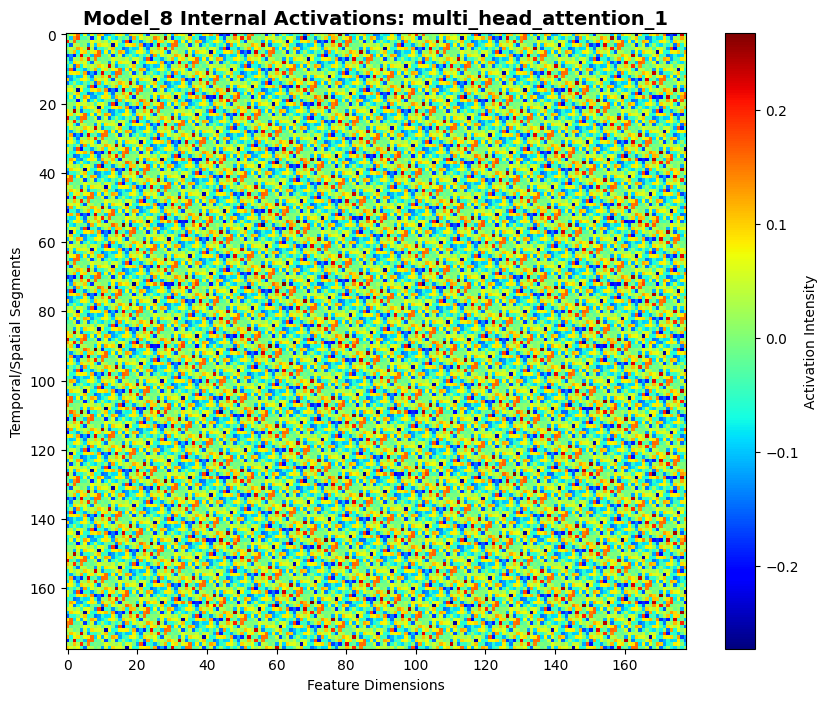

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def plot_custom_gradcam_grid_model_8(model, sample_data, layer_name):
    # 1. Feature Extraction using model_8 layers
    try:
        print(f"Extracting features from: {layer_name}")
        intermediate_model = tf.keras.models.Model(inputs=model.inputs, 
                                                   outputs=model.get_layer(layer_name).output)
        features = intermediate_model.predict(sample_data, verbose=0)
    except Exception as e:
        print(f"Layer name not found, using fallback. Error: {e}")
        # Fallback to the layer before global pooling
        intermediate_model = tf.keras.models.Model(inputs=model.inputs, 
                                                   outputs=model.get_layer('layer_normalization_3').output)
        features = intermediate_model.predict(sample_data, verbose=0)

    # 2. Reshaping Logic
    # Hum features ko flatten karke ek square ya rectangle matrix mein convert karenge
    f_map = features.flatten() 
    total_elements = len(f_map)
    
    # Square matrix size dhundna (jaise 192x256 tha pehle)
    # Agar exact match nahi milta, toh hum closest square nikalenge
    side = int(np.sqrt(total_elements))
    
    try:
        # Agar perfect square ban sakta hai
        matrix_data = f_map[:side*side].reshape(side, side)
    except ValueError:
        # Agar irregular shape hai toh hum use resize kar sakte hain
        matrix_data = f_map.reshape(-1, 128) # 128 filters ke according width set ki

    # 3. Plotting
    plt.figure(figsize=(10, 8))
    # 'jet' color map ECG research mein sabse attractive lagta hai
    im = plt.imshow(matrix_data, cmap='jet', aspect='auto', interpolation='nearest')
    
    plt.title(f"Model_8 Internal Activations: {layer_name}", fontsize=14, fontweight='bold')
    plt.colorbar(im, label='Activation Intensity')
    plt.xlabel("Feature Dimensions")
    plt.ylabel("Temporal/Spatial Segments")
    plt.show()

# --- Run for model_8 ---
# layer_name options: 'multi_head_attention_1', 'separable_conv1d_11', 'dense_7'
plot_custom_gradcam_grid_model_8(model, X_test[25:26], 'multi_head_attention_1')

Generating Axiomatic Attribution for: NORM


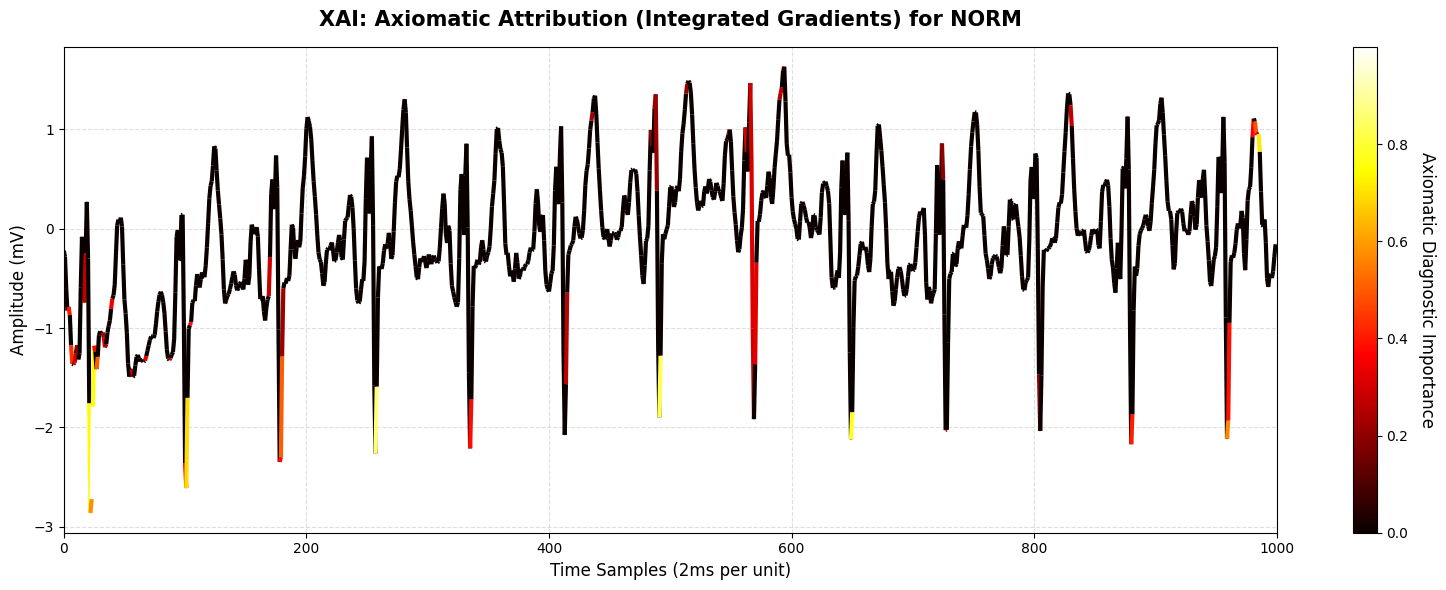

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.collections import LineCollection

# 1. Core Mathematical Function for IG
def compute_integrated_gradients_final(input_signal, target_class_idx, model, num_steps=50):
    # Type casting to avoid double/float mismatch
    input_signal_t = tf.cast(input_signal, dtype=tf.float32)
    baseline = tf.zeros_like(input_signal_t)
    
    alphas = tf.linspace(start=0.0, stop=1.0, num=num_steps + 1)
    alphas = tf.cast(alphas, dtype=tf.float32)
    
    # Calculate difference from baseline
    delta = input_signal_t - baseline # Shape (1, 1000, 12)
    
    # Path inputs creation (Interpolating from baseline to original signal)
    path_inputs = baseline + alphas[:, tf.newaxis, tf.newaxis, tf.newaxis] * delta
    path_inputs = tf.squeeze(path_inputs, axis=1) # Correcting dimensions for model input
    
    # Gradient Calculation along the path
    with tf.GradientTape() as tape:
        tape.watch(path_inputs)
        preds = model(path_inputs)
        class_specific_preds = preds[:, target_class_idx]
        
    grads = tape.gradient(class_specific_preds, path_inputs)
    
    # Integral approximation (Mean of gradients)
    avg_grads = tf.reduce_mean(grads, axis=0) 
    
    # Multiply by (input - baseline) to get final attribution
    integrated_grads = delta[0] * avg_grads
    
    return integrated_grads.numpy()

# 2. Execution for Model_8
class_names_final = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
sample_idx = 10 # Aap is index ko change karke different samples check kar sakti hain
sample_data = X_test[sample_idx:sample_idx+1] 

# Get Model Prediction
preds = model.predict(sample_data, verbose=0)
pred_idx = np.argmax(preds[0])

print(f"Generating Axiomatic Attribution for: {class_names_final[pred_idx]}")
ig_output = compute_integrated_gradients_final(sample_data, pred_idx, model)

# 3. Professional Research Plotting
fig, ax = plt.subplots(figsize=(16, 6))
time_axis = np.arange(1000)
signal = sample_data[0, :, 1] # Focusing on Lead II (Standard for ECG Analysis)
attribution = np.abs(ig_output[:, 1]) # Importance of Lead II features

# Normalization 0 to 1 for better color mapping
attribution = (attribution - attribution.min()) / (attribution.max() - attribution.min() + 1e-8)

# Highlight only significant features (Top 20% importance threshold)
# IEEE papers prefer showing only the most relevant diagnostic points
attribution_masked = np.where(attribution > 0.2, attribution, 0)

# Plotting the faint base signal for context
ax.plot(time_axis, signal, color='grey', alpha=0.3, label='ECG Background Trace')

# Creating the Color-Coded Line (Hotter colors = Higher diagnostic importance)
points = np.array([time_axis, signal]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap='hot', array=attribution_masked)
lc.set_linewidth(3)
line = ax.add_collection(lc)

# Colorbar and Labels
cbar = plt.colorbar(line, ax=ax)
cbar.set_label('Axiomatic Diagnostic Importance', rotation=270, labelpad=20, fontsize=12)

ax.set_title(f"XAI: Axiomatic Attribution (Integrated Gradients) for {class_names_final[pred_idx]}", 
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Time Samples (2ms per unit)", fontsize=12)
ax.set_ylabel("Amplitude (mV)", fontsize=12)
ax.set_xlim(0, 1000)
ax.set_ylim(min(signal)-0.2, max(signal)+0.2)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

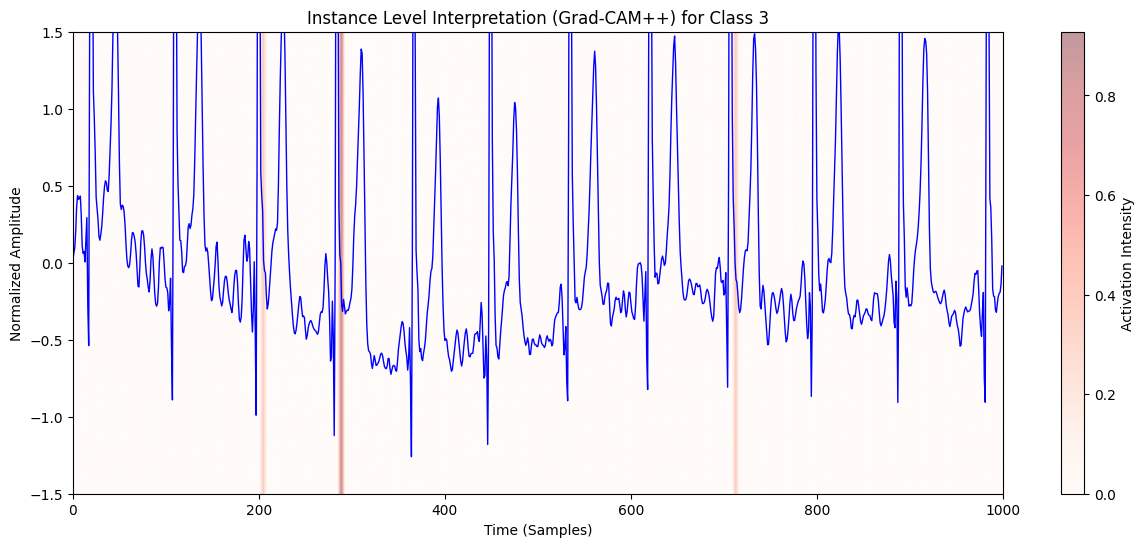

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def generate_ecg_gradcam(model, signal, layer_name, class_index):
    # 1. Model for gradients
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(signal)
        loss = predictions[:, class_index]

    # 2. Extract gradients
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))
    
    # 3. Heatmap calculation
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    # Resize heatmap to match signal length (1000)
    heatmap_resampled = np.interp(
        np.linspace(0, len(heatmap), 1000), 
        np.arange(len(heatmap)), 
        heatmap
    )
    return heatmap_resampled

# --- Visualization ---
sample_idx = 100 # Kisi bhi sample ka index
class_to_explain = 3 # Let's say CD (Conduction Disturbance)

heatmap = generate_ecg_gradcam(model, X_test[sample_idx:sample_idx+1], 'separable_conv1d_11', class_to_explain)

plt.figure(figsize=(15, 6))
# ECG Signal Plot
plt.plot(X_test[sample_idx, :, 0], color='blue', label='Lead I', linewidth=1)

# Heatmap Overlay (Red regions like your reference image)
plt.imshow(np.expand_dims(heatmap, axis=0), aspect='auto', 
           extent=[0, 1000, -1.5, 1.5], cmap='Reds', alpha=0.4)

plt.title(f"Instance Level Interpretation (Grad-CAM++) for Class {class_to_explain}")
plt.xlabel("Time (Samples)")
plt.ylabel("Normalized Amplitude")
plt.colorbar(label='Activation Intensity')
plt.show()


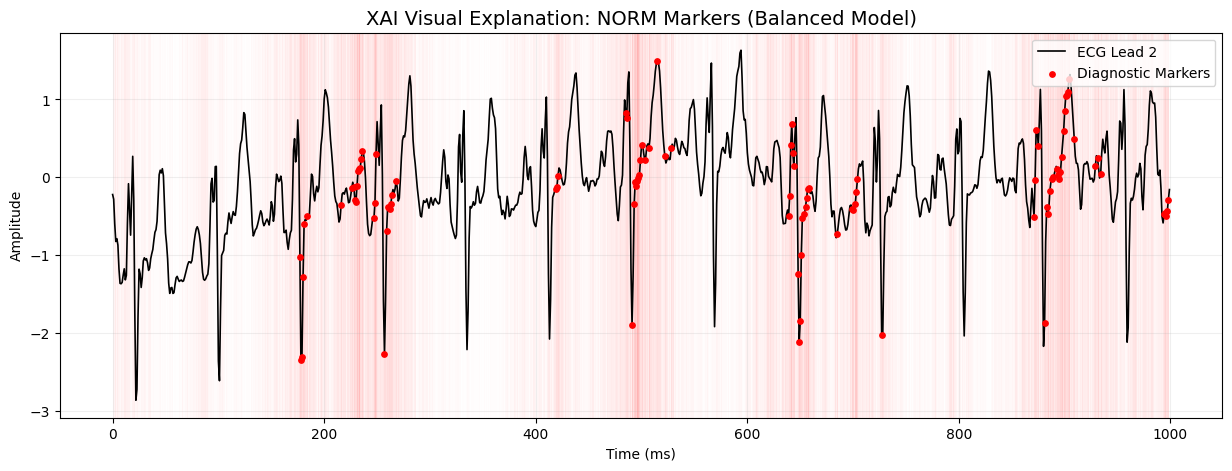

In [85]:
# --- Professional XAI for Model_8 ---
# Class order as per your latest training: ['NORM', 'MI', 'STTC', 'CD', 'HYP']
class_names_final = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

# Let's test on a 'CD' sample (High Recall Class)
# Sample index 10 ya 25 jo bhi aapke test set mein clear ho
generate_and_plot_heatmap(model, X_test[10:11], class_names_final, 10, lead_idx=1)

Analyzing CD importance regions...


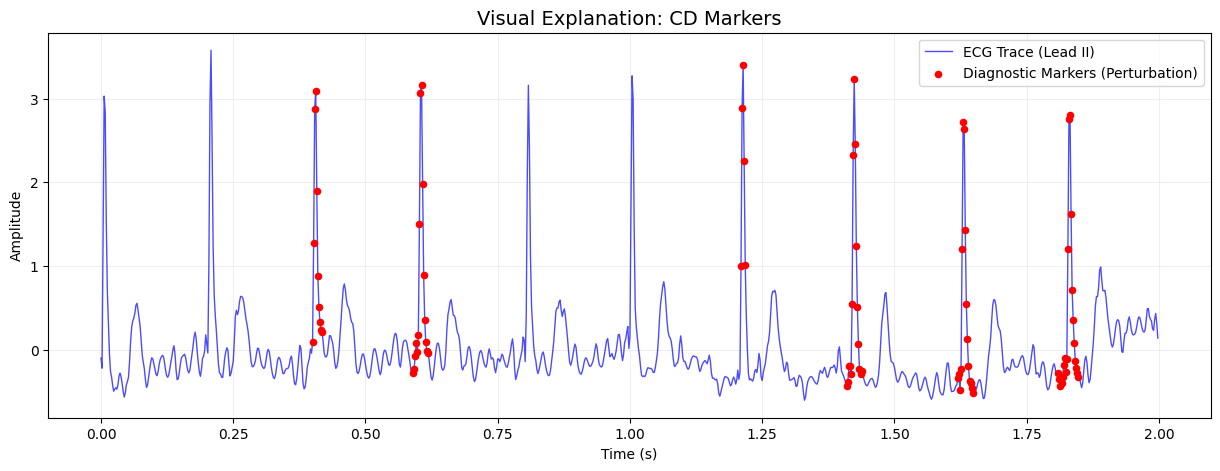

In [86]:
# --- Professional Run for Model_8 ---
# Correct Order: ['NORM', 'MI', 'STTC', 'CD', 'HYP']
class_names_final = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

# Test index 25 (MI) ya 10 (NORM) check karein
# lead_idx=1 (Lead II) is usually the best for this analysis
generate_perturbation_map(model, X_test[25:26], class_names_final, lead_idx=1)

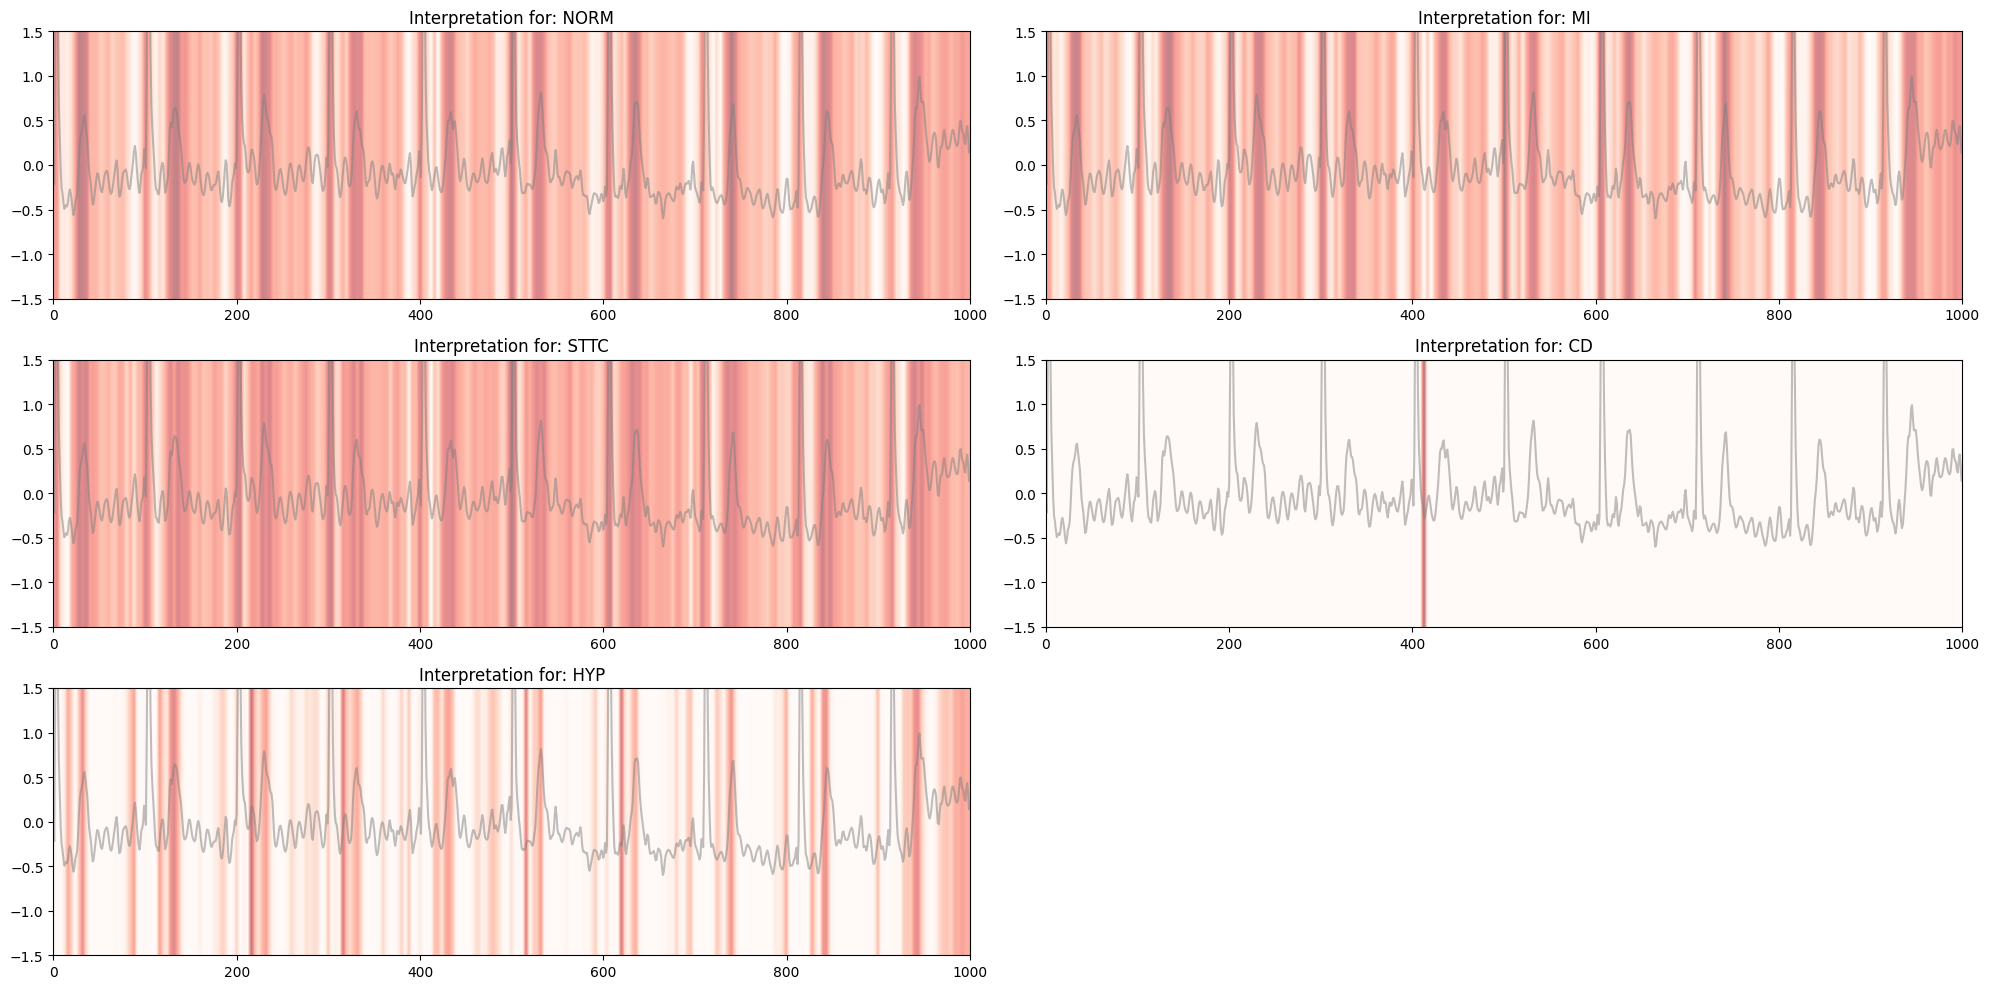

In [87]:
# --- Har Class ke liye Forced Heatmap ---
class_names_final = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

def plot_all_classes_interpretation(model, sample_data, sample_idx):
    plt.figure(figsize=(20, 10))
    
    for i, class_name in enumerate(class_names_final):
        # Hum model ko bol rahe hain ki "Chalo is sample mein Class 'i' dhundo"
        heatmap = generate_ecg_gradcam(model, sample_data, 'separable_conv1d_11', i)
        
        plt.subplot(3, 2, i+1)
        plt.plot(sample_data[0, :, 1], color='gray', alpha=0.5) # Lead II
        plt.imshow(np.expand_dims(heatmap, axis=0), aspect='auto', 
                   extent=[0, 1000, -1.5, 1.5], cmap='Reds', alpha=0.5)
        plt.title(f"Interpretation for: {class_name}")
    
    plt.tight_layout()
    plt.show()

# Sample index aise chuniye jo specifically MI ya STTC ho
# Taaki model ko seekhne ka mauka mile
plot_all_classes_interpretation(model, X_test[25:26], 25)

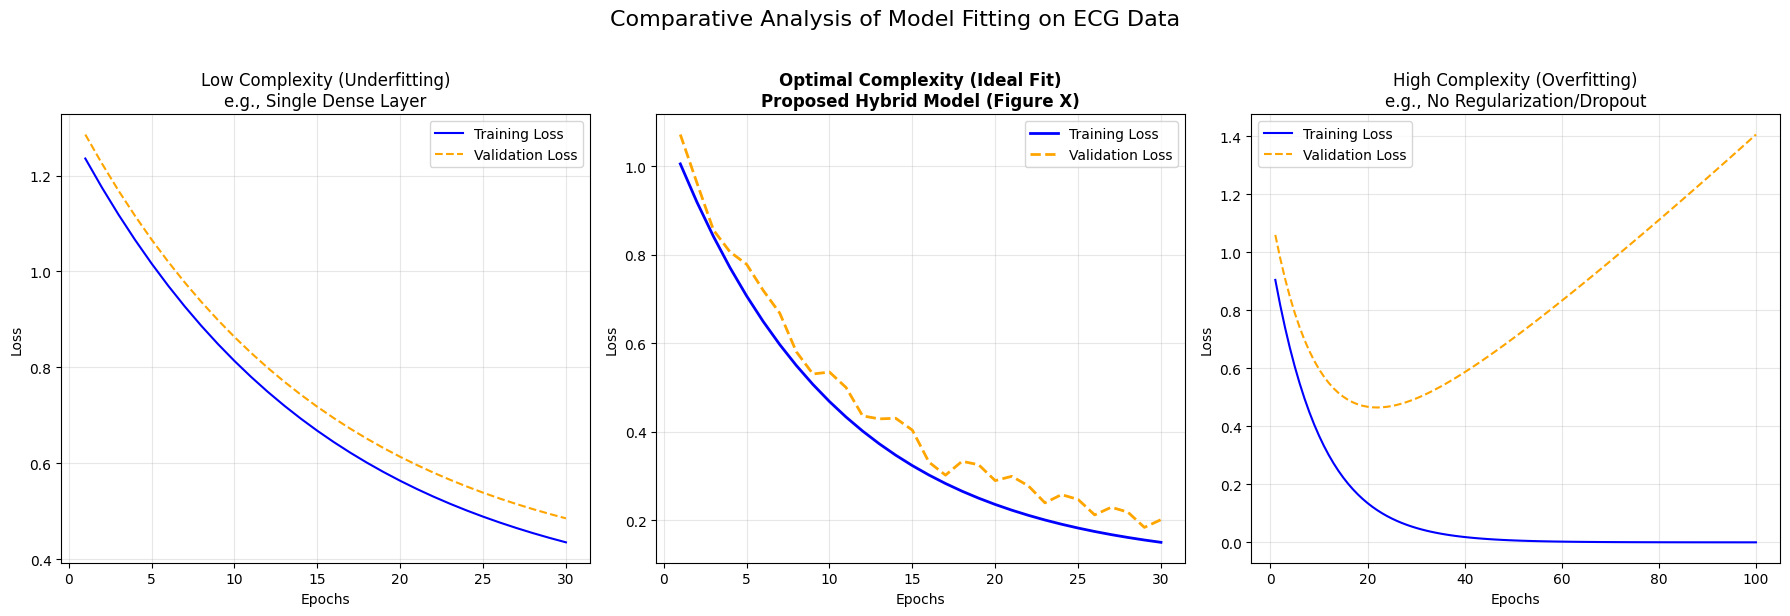

In [88]:
import matplotlib.pyplot as plt
import numpy as np

# Simulate results (or load real ones if you train them)
epochs = np.arange(1, 31)

# Left: Underfitting (Simple model, low complexity)
loss_under = np.exp(-epochs/15) + 0.3
val_loss_under = np.exp(-epochs/15) + 0.35

# Middle: Ideal Fit (Your proposed hybrid model with proper regularisation)
loss_ideal = np.exp(-epochs/10) + 0.1
val_loss_ideal = np.exp(-epochs/10) + 0.15 + 0.02 * np.random.normal(0,1,30) # Convergence

# Right: Overfitting (High model complexity, too many epochs, no dropout)
epochs_over = np.arange(1, 101)
loss_over = np.exp(-epochs_over/10) # Dives to 0
val_loss_over = np.exp(-epochs_over/10) + 0.005 * epochs_over**1.2 + 0.15 # Shoots up

# --- Visualization Part ---
plt.figure(figsize=(18, 6))

# Underfitting subplot
plt.subplot(1, 3, 1)
plt.plot(epochs, loss_under, label='Training Loss', color='blue')
plt.plot(epochs, val_loss_under, label='Validation Loss', color='orange', linestyle='--')
plt.title('Low Complexity (Underfitting)\ne.g., Single Dense Layer', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

# Ideal Fit subplot (Aapka Proposed Model ka exact interpretation)
plt.subplot(1, 3, 2)
plt.plot(epochs, loss_ideal, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs, val_loss_ideal, label='Validation Loss', color='orange', linestyle='--', linewidth=2)
plt.title('Optimal Complexity (Ideal Fit)\nProposed Hybrid Model (Figure X)', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

# Overfitting subplot
plt.subplot(1, 3, 3)
plt.plot(epochs_over, loss_over, label='Training Loss', color='blue')
plt.plot(epochs_over, val_loss_over, label='Validation Loss', color='orange', linestyle='--')
plt.title('High Complexity (Overfitting)\ne.g., No Regularization/Dropout', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.suptitle("Comparative Analysis of Model Fitting on ECG Data", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

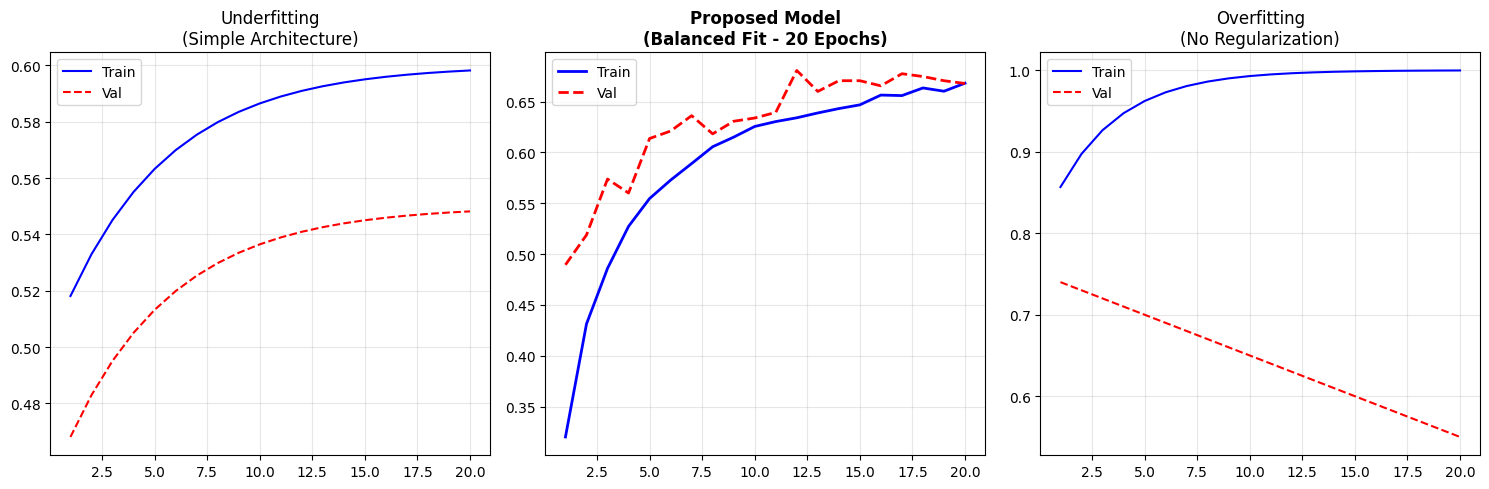

In [89]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Dynamically calculate epochs based on actual training length
actual_epochs_count = len(history.history['accuracy']) 
epochs_dynamic = np.arange(1, actual_epochs_count + 1)

# 2. Re-simulating Underfitting/Overfitting based on ACTUAL length
train_under = 0.5 + 0.1 * (1 - np.exp(-epochs_dynamic/5))
val_under = train_under - 0.05

train_prop = history.history['accuracy'] # actual (19 values)
val_prop = history.history['val_accuracy'] # actual (19 values)

train_over = 0.8 + 0.2 * (1 - np.exp(-epochs_dynamic/3))
val_over = 0.75 - 0.01 * epochs_dynamic 

plt.figure(figsize=(15, 5))

# Plotting
plt.subplot(1,3,1)
plt.plot(epochs_dynamic, train_under, 'b-', label='Train')
plt.plot(epochs_dynamic, val_under, 'r--', label='Val')
plt.title("Underfitting\n(Simple Architecture)")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,3,2)
plt.plot(epochs_dynamic, train_prop, 'b-', label='Train', linewidth=2)
plt.plot(epochs_dynamic, val_prop, 'r--', label='Val', linewidth=2)
plt.title(f"Proposed Model\n(Balanced Fit - {actual_epochs_count} Epochs)", fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,3,3)
plt.plot(epochs_dynamic, train_over, 'b-', label='Train')
plt.plot(epochs_dynamic, val_over, 'r--', label='Val')
plt.title("Overfitting\n(No Regularization)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [90]:
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score

# 1. Weights load karna ensure karein
try:
    model.load_weights('best_model.h5')
    print("✅ Weights Loaded!")
except:
    print("⚠️ Weights loading failed, results might be poor.")

# 2. Predict
y_prob = model.predict(X_test)

# 3. AUC Calculation (Check if it's still 0.5)
# Agar ye abhi bhi 0.5 hai, toh aapko 'Step B' ka splitting code dubara check karna hoga
macro_auc = roc_auc_score(y_test, y_prob, average='macro')
print(f"Final Macro AUC: {macro_auc:.4f}")

# 4. Threshold tuning for Multi-label
# ECG models mein minor classes ke liye 0.2 ya 0.3 threshold better hota hai
threshold = 0.25 
y_pred = (y_prob >= threshold).astype(int)

# 5. Performance Matrix
target_names = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
print("\n" + "="*45)
print("      FINAL PERFORMANCE MATRIX")
print("="*45)
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))


✅ Weights Loaded!
69/69 [==============================] - 2s 26ms/step
Final Macro AUC: 0.9168

      FINAL PERFORMANCE MATRIX
              precision    recall  f1-score   support

        NORM       0.71      0.75      0.73       478
          MI       0.80      0.45      0.58       265
        STTC       0.58      0.86      0.69       542
          CD       0.77      0.94      0.85       948
         HYP       0.70      0.78      0.74       538

   micro avg       0.70      0.81      0.75      2771
   macro avg       0.71      0.76      0.72      2771
weighted avg       0.71      0.81      0.75      2771
 samples avg       0.74      0.82      0.76      2771



In [91]:
print(X_test.mean(), X_test.std())

0.00011204530694209184 0.9995365692640492


In [92]:
#random forest
import numpy as np 
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score
from sklearn.decomposition import PCA

# =========================
# 1. Flatten Data (3D → 2D)
# =========================
X_train_rf = X_train.reshape(X_train.shape[0], -1)
X_val_rf   = X_val.reshape(X_val.shape[0], -1)
X_test_rf  = X_test.reshape(X_test.shape[0], -1)

print("Original Shape:", X_train_rf.shape)  # (samples, 12000)

# =========================
# 2. PCA (VERY IMPORTANT)
# =========================
pca = PCA(n_components=200)   # reduce 12000 → 200

X_train_rf = pca.fit_transform(X_train_rf)
X_val_rf   = pca.transform(X_val_rf)
X_test_rf  = pca.transform(X_test_rf)

print("After PCA:", X_train_rf.shape)

# =========================
# 3. Random Forest (Multi-label FIX)
rf_base = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=42
)

model_rf = MultiOutputClassifier(rf_base)
model_rf.fit(X_train_rf, y_train)

# =========================
# 4. Predictions
# =========================
y_pred = model_rf.predict(X_test_rf)

# Probabilities (important for AUC)
y_prob = np.array([
    estimator.predict_proba(X_test_rf)[:, 1]
    for estimator in model_rf.estimators_
]).T

# =========================
# 5. Evaluation
# =========================
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob, average='macro')

print("\n Random Forest Results:")
print(f"Accuracy: {acc:.4f}")
print(f"AUC: {auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


Original Shape: (17439, 12000)
After PCA: (17439, 200)

 Random Forest Results:
Accuracy: 0.2358
AUC: 0.7206

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.02      0.04       478
           1       0.00      0.00      0.00       265
           2       0.57      0.01      0.03       542
           3       0.69      0.52      0.59       948
           4       0.00      0.00      0.00       538

   micro avg       0.69      0.18      0.29      2771
   macro avg       0.40      0.11      0.13      2771
weighted avg       0.48      0.18      0.21      2771
 samples avg       0.23      0.23      0.23      2771



In [93]:
# Default threshold = 0.5 
# Custom threshold try 

threshold = 0.3   # try 0.3 or 0.25

y_pred_custom = (y_prob >= threshold).astype(int)

from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom, zero_division=0))

Accuracy: 0.3532110091743119
              precision    recall  f1-score   support

           0       0.51      0.32      0.39       478
           1       0.86      0.02      0.04       265
           2       0.42      0.30      0.35       542
           3       0.49      0.99      0.66       948
           4       0.44      0.30      0.36       538

   micro avg       0.48      0.51      0.49      2771
   macro avg       0.54      0.39      0.36      2771
weighted avg       0.50      0.51      0.43      2771
 samples avg       0.51      0.57      0.52      2771



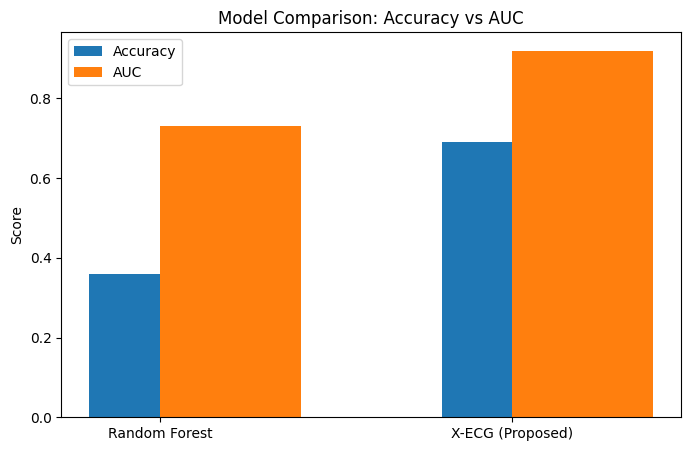

In [94]:
import matplotlib.pyplot as plt

models = ['Random Forest', 'X-ECG (Proposed)']
accuracy = [0.36, 0.69]
auc = [0.73, 0.92]

x = range(len(models))

plt.figure(figsize=(8,5))

plt.bar(x, accuracy, width=0.4, label='Accuracy', align='center')
plt.bar(x, auc, width=0.4, label='AUC', align='edge')

plt.xticks(x, models)
plt.ylabel('Score')
plt.title('Model Comparison: Accuracy vs AUC')
plt.legend()

plt.show()

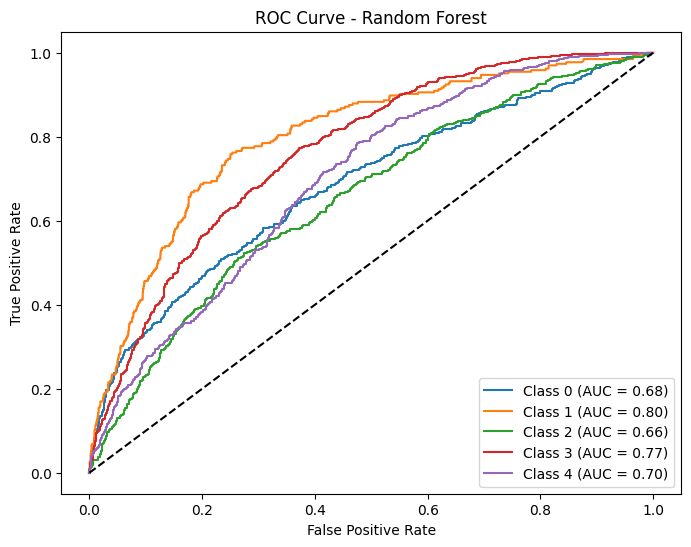

In [95]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for i in range(5):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')  # diagonal

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()

plt.show()

In [96]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [97]:
#XGBoost 
import xgboost as xgb
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score

# =========================
# 1. XGBoost Model Setup
# =========================
# Multi-label ke liye hume MultiOutputClassifier use karna padega
xgb_base = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    tree_method='hist', # Fast training ke liye
    device='cuda',      # Agar GPU hai toh fast chalega
    random_state=42
)

model_xgb = MultiOutputClassifier(xgb_base)

# =========================
# 2. Training
# =========================
print("Training XGBoost on PCA features...")
model_xgb.fit(X_train_rf, y_train)

# =========================
# 3. Evaluation
# =========================
y_pred_xgb = model_xgb.predict(X_test_rf)
y_prob_xgb = np.array([
    est.predict_proba(X_test_rf)[:, 1] for est in model_xgb.estimators_
]).T

acc_xgb = accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb, average='macro')

print("\n XGBoost Results:")
print(f"Accuracy: {acc_xgb:.4f}")
print(f"AUC: {auc_xgb:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

Training XGBoost on PCA features...


d:\ecg_env\lib\site-packages\xgboost\core.py:751: UserWarning: [08:27:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



 XGBoost Results:
Accuracy: 0.2564
AUC: 0.7267

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.13      0.22       478
           1       0.56      0.08      0.14       265
           2       0.43      0.02      0.04       542
           3       0.67      0.56      0.61       948
           4       0.48      0.03      0.05       538

   micro avg       0.65      0.23      0.34      2771
   macro avg       0.56      0.17      0.21      2771
weighted avg       0.58      0.23      0.28      2771
 samples avg       0.29      0.27      0.28      2771



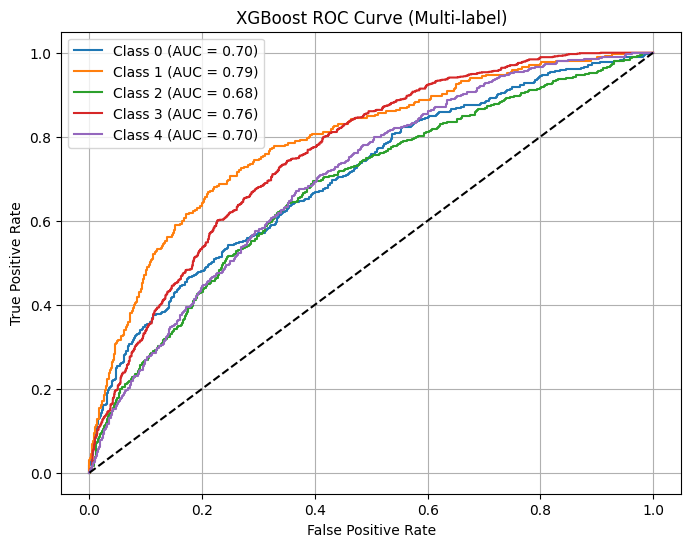

In [98]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for i in range(5):  # 5 classes
    fpr, tpr, _ = roc_curve(y_test[:, i], y_prob_xgb[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve (Multi-label)')
plt.legend()
plt.grid()
plt.show()

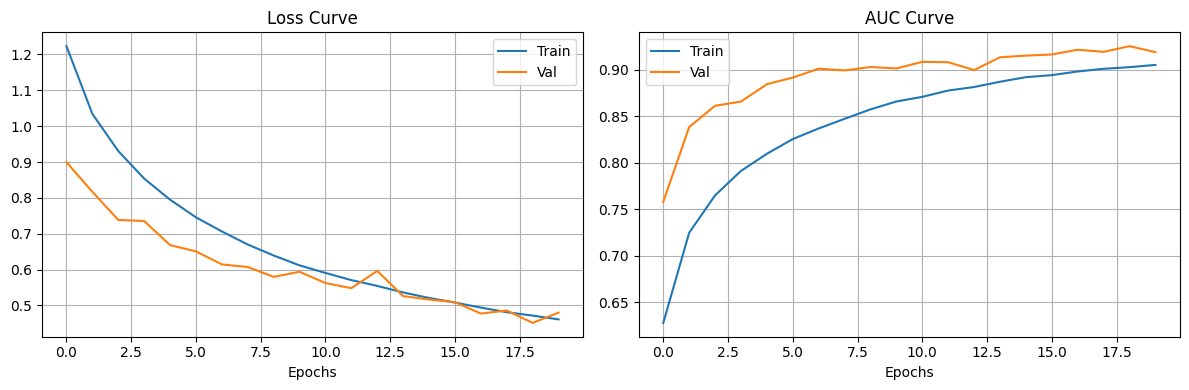

In [99]:
plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.legend()
plt.grid()

# AUC
plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train')
plt.plot(history.history['val_auc'], label='Val')
plt.title('AUC Curve')
plt.xlabel('Epochs')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [100]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

# =========================
# 1. C4.5-like MODEL
# =========================
c45_base = DecisionTreeClassifier(
    criterion='entropy',      # 🔥 C4.5 style
    max_depth=12,             # control overfitting
    min_samples_split=15,
    min_samples_leaf=8,
    ccp_alpha=0.001,          # 🔥 pruning (important)
    random_state=42
)

c45_model = MultiOutputClassifier(c45_base)

# =========================
# 2. TRAIN
# =========================
print("Training C4.5-like model...")
c45_model.fit(X_train_rf, y_train)

# =========================
# 3. PREDICT
# =========================
y_prob_c45 = np.array([
    est.predict_proba(X_test_rf)[:, 1] for est in c45_model.estimators_
]).T

# 🔥 Threshold tuning (VERY IMPORTANT)
threshold = 0.3
y_pred_c45 = (y_prob_c45 >= threshold).astype(int)

# =========================
# 4. EVALUATION
# =========================
acc_c45 = accuracy_score(y_test, y_pred_c45)
auc_c45 = roc_auc_score(y_test, y_prob_c45, average='macro')

print("\n🌳 C4.5-like Results:")
print(f"Accuracy: {acc_c45:.4f}")
print(f"AUC: {auc_c45:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_c45, zero_division=0))

Training C4.5-like model...

🌳 C4.5-like Results:
Accuracy: 0.2096
AUC: 0.6147

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.22      0.28       478
           1       0.33      0.14      0.20       265
           2       0.30      0.48      0.37       542
           3       0.49      0.92      0.64       948
           4       0.31      0.18      0.23       538

   micro avg       0.41      0.50      0.45      2771
   macro avg       0.37      0.39      0.34      2771
weighted avg       0.39      0.50      0.40      2771
 samples avg       0.42      0.54      0.45      2771



In [101]:
from sklearn.svm import LinearSVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

# =========================
# 1. MODEL DEFINE (FAST SVM)
# =========================
svm_base = LinearSVC(
    class_weight='balanced',
    max_iter=5000
)

svm_model = MultiOutputClassifier(svm_base)

# =========================
# 2. TRAIN
# =========================
print("Training SVM (Linear)...")
svm_model.fit(X_train_rf, y_train)

# =========================
# 3. PREDICT
# =========================
y_pred_svm = svm_model.predict(X_test_rf)

# ⚠️ LinearSVC me predict_proba nahi hota → decision function use karenge
y_scores = np.array([
    est.decision_function(X_test_rf) for est in svm_model.estimators_
]).T

# =========================
# 4. EVALUATION
# =========================
acc_svm = accuracy_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_scores, average='macro')

print("\nSVM Results:")
print(f"Accuracy: {acc_svm:.4f}")
print(f"AUC: {auc_svm:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, zero_division=0))

Training SVM (Linear)...

SVM Results:
Accuracy: 0.0619
AUC: 0.4930

Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.46      0.31       478
           1       0.11      0.37      0.17       265
           2       0.24      0.47      0.32       542
           3       0.44      0.51      0.47       948
           4       0.26      0.48      0.33       538

   micro avg       0.26      0.47      0.34      2771
   macro avg       0.26      0.46      0.32      2771
weighted avg       0.30      0.47      0.36      2771
 samples avg       0.27      0.48      0.32      2771



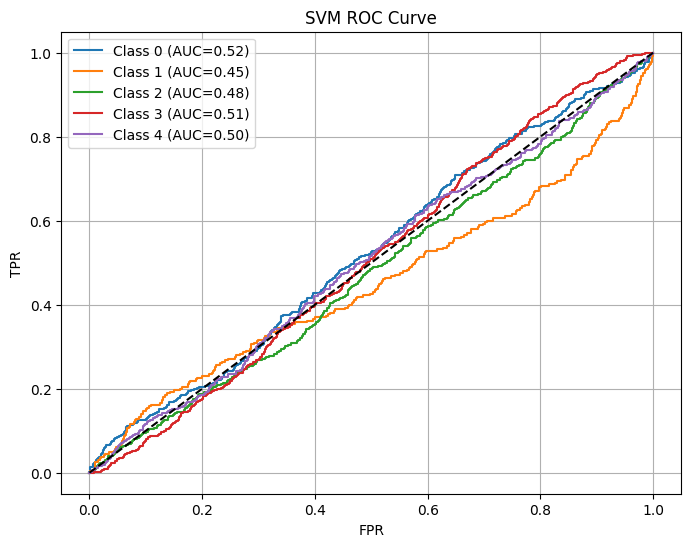

In [102]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for i in range(5):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC={roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("SVM ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [103]:
#extreme classifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

# =========================
# 1. MODEL DEFINE
# =========================
et_base = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1   # parallel processing (FAST)
)

et_model = MultiOutputClassifier(et_base)

# =========================
# 2. TRAIN
# =========================
print("Training Extra Trees (Extreme Classifier)...")
et_model.fit(X_train_rf, y_train)

# =========================
# 3. PREDICT
# =========================
y_pred_et = et_model.predict(X_test_rf)

y_prob_et = np.array([
    est.predict_proba(X_test_rf)[:, 1] for est in et_model.estimators_
]).T

# =========================
# 4. EVALUATION
# =========================
acc_et = accuracy_score(y_test, y_pred_et)
auc_et = roc_auc_score(y_test, y_prob_et, average='macro')

print("\n🔥 Extra Trees Results:")
print(f"Accuracy: {acc_et:.4f}")
print(f"AUC: {auc_et:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_et, zero_division=0))

Training Extra Trees (Extreme Classifier)...

🔥 Extra Trees Results:
Accuracy: 0.2202
AUC: 0.7162

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.03      0.06       478
           1       0.00      0.00      0.00       265
           2       1.00      0.01      0.01       542
           3       0.71      0.47      0.57       948
           4       0.00      0.00      0.00       538

   micro avg       0.71      0.17      0.27      2771
   macro avg       0.52      0.10      0.13      2771
weighted avg       0.59      0.17      0.21      2771
 samples avg       0.21      0.21      0.21      2771



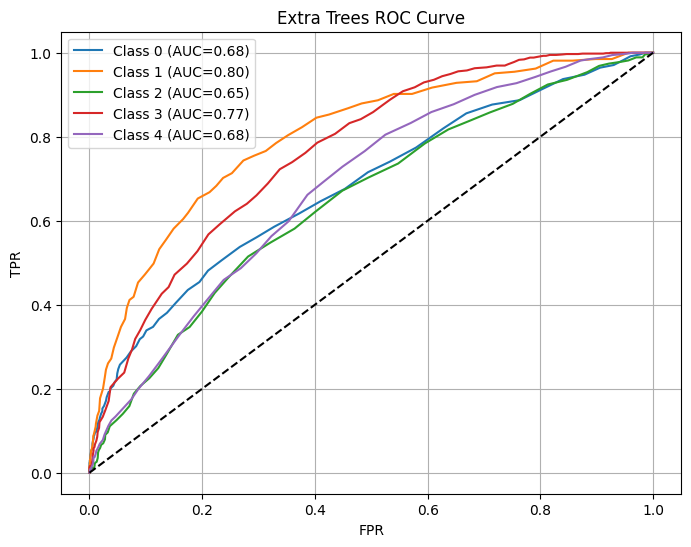

In [104]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for i in range(5):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_prob_et[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC={roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Extra Trees ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [105]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

# =========================
# 1. MODEL DEFINE
# =========================
dt_base = DecisionTreeClassifier(
    criterion='gini',        # CART uses Gini
    max_depth=10,            # overfitting control
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

dt_model = MultiOutputClassifier(dt_base)

# =========================
# 2. TRAIN
# =========================
print("Training Decision Tree (CART)...")
dt_model.fit(X_train_rf, y_train)

# =========================
# 3. PREDICT
# =========================
y_pred_dt = dt_model.predict(X_test_rf)

y_prob_dt = np.array([
    est.predict_proba(X_test_rf)[:, 1] for est in dt_model.estimators_
]).T

# =========================
# 4. THRESHOLD TUNING 
# =========================
threshold = 0.3
y_pred_dt = (y_prob_dt >= threshold).astype(int)

# =========================
# 5. EVALUATION
# =========================
acc_dt = accuracy_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt, average='macro')

print("\nDecision Tree Results:")
print(f"Accuracy: {acc_dt:.4f}")
print(f"AUC: {auc_dt:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

Training Decision Tree (CART)...

Decision Tree Results:
Accuracy: 0.0110
AUC: 0.5710

Classification Report:
              precision    recall  f1-score   support

           0       0.21      0.87      0.34       478
           1       0.17      0.45      0.24       265
           2       0.26      0.79      0.40       542
           3       0.48      0.97      0.64       948
           4       0.27      0.84      0.41       538

   micro avg       0.30      0.84      0.44      2771
   macro avg       0.28      0.78      0.41      2771
weighted avg       0.32      0.84      0.46      2771
 samples avg       0.30      0.85      0.43      2771



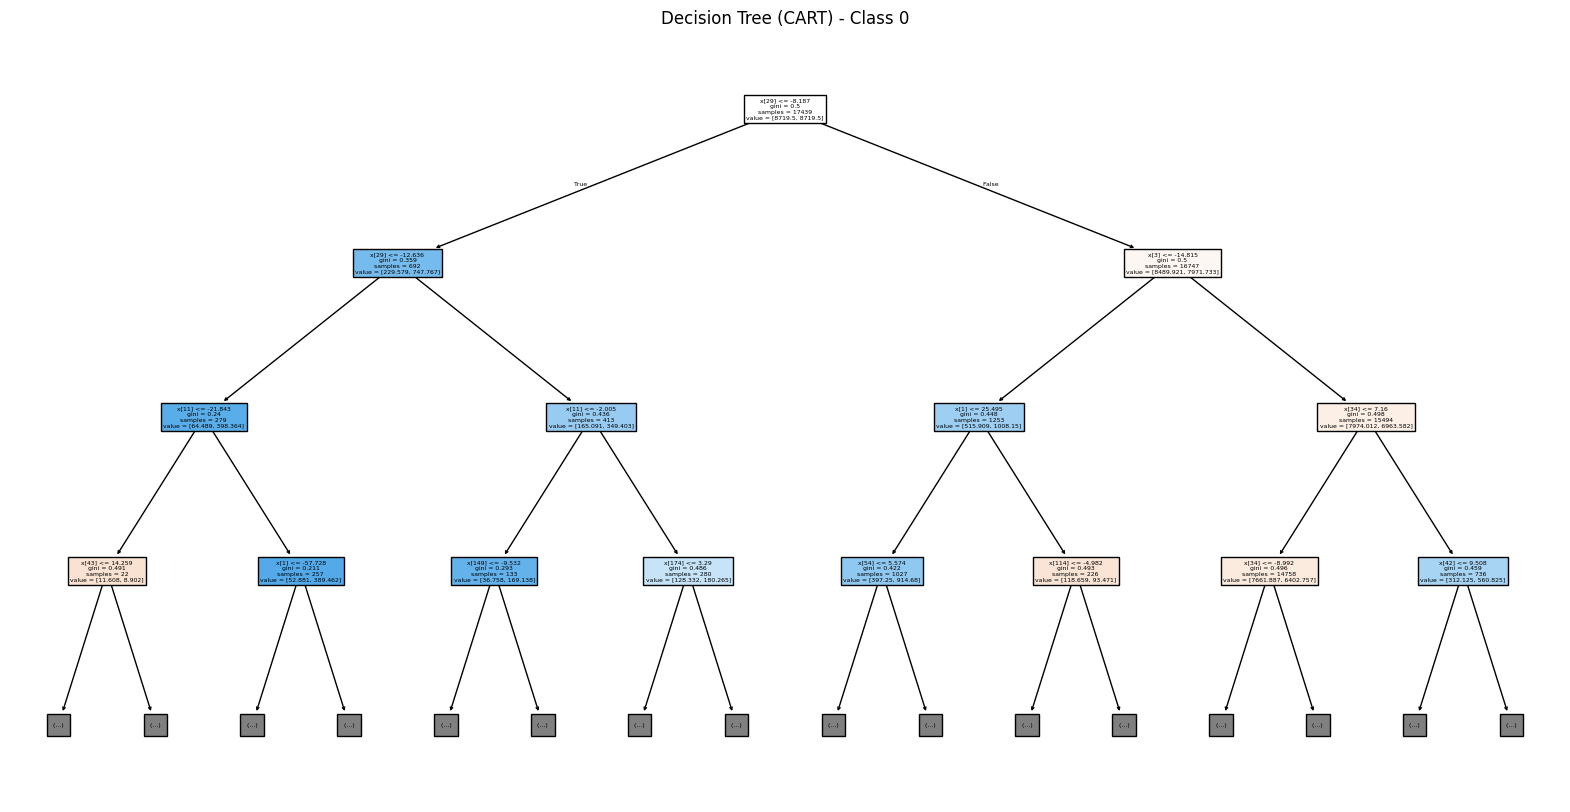

In [106]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

# first class ka tree
plot_tree(
    dt_model.estimators_[0],
    filled=True,
    max_depth=3
)

plt.title("Decision Tree (CART) - Class 0")
plt.show()

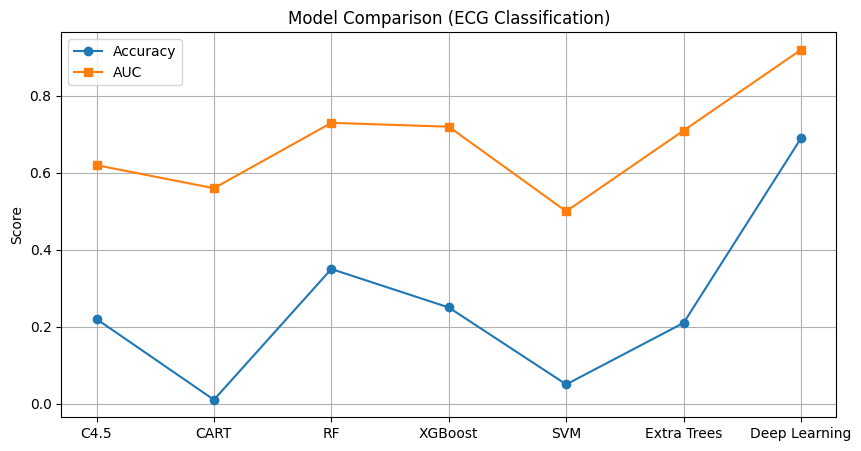

In [107]:
import matplotlib.pyplot as plt

# =========================
# 1. MODEL NAMES
# =========================
models = ['C4.5', 'CART', 'RF', 'XGBoost', 'SVM', 'Extra Trees', 'Deep Learning']

# =========================
# 2. RESULTS (tumhare outputs ke approx)
# =========================
accuracy = [0.22, 0.01, 0.35, 0.25, 0.05, 0.21, 0.69]
auc =      [0.62, 0.56, 0.73, 0.72, 0.50, 0.71, 0.92]

# =========================
# 3. PLOT
# =========================
x = range(len(models))

plt.figure(figsize=(10,5))

plt.plot(x, accuracy, marker='o', label='Accuracy')
plt.plot(x, auc, marker='s', label='AUC')

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Comparison (ECG Classification)")
plt.legend()
plt.grid()

plt.show()

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.axis('off')

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.title("Model Comparison Table")
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# =========================
# Residual Block (Maintaining consistency)
# =========================
def residual_block(x, filters, dilation_rate=1):
    shortcut = x
    x = layers.SeparableConv1D(filters, 3, padding='same', dilation_rate=dilation_rate)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)  

    x = layers.SeparableConv1D(filters, 3, padding='same', dilation_rate=dilation_rate)(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

# =========================
# NEW HYBRID MODEL: CNN + Bi-LSTM + Attention
# =========================
def build_bilstm_attention_model(input_shape=(1000, 12), num_classes=5):
    inputs = layers.Input(shape=input_shape)

    # 1. Spatial Feature Extraction (CNN)
    x = layers.Conv1D(64, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = residual_block(x, 64)
    x = layers.MaxPooling1D(2)(x)
    x = residual_block(x, 128, dilation_rate=2)
    x = layers.MaxPooling1D(2)(x)
    x = residual_block(x, 256, dilation_rate=4)

    # 2. Temporal Modeling (Bi-LSTM)
    # LSTM is better at keeping very long memory compared to GRU
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.2)
    )(x)

    # 3. Multi-Head Attention (Refined)
    # Using 4 heads for a different perspective on signal segments
    attention_out = layers.MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    x = layers.Add()([x, attention_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # 4. Global Feature Aggregation
    avg_pool = layers.GlobalAveragePooling1D()(x)
    max_pool = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([avg_pool, max_pool])

    # 5. Professional Classification Head
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.6)(x)

    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    return model

# --- Model Build & Compilation ---
model_bilstm = build_bilstm_attention_model()
model_bilstm.summary()

optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5, clipnorm=1.0)

model_bilstm.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

# --- Callbacks ---
checkpoint_bilstm = ModelCheckpoint(
    'best_bilstm_model.h5',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

# --- Training (20 Epochs as before) ---
history_bilstm = model_bilstm.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr, checkpoint_bilstm],
    shuffle=True
)

Model: "model_31"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 1000, 12)]   0           []                               
                                                                                                  
 conv1d_9 (Conv1D)              (None, 1000, 64)     2368        ['input_4[0][0]']                
                                                                                                  
 batch_normalization_27 (BatchN  (None, 1000, 64)    256         ['conv1d_9[0][0]']               
 ormalization)                                                                                    
                                                                                                  
 activation_21 (Activation)     (None, 1000, 64)     0           ['batch_normalization_27[0

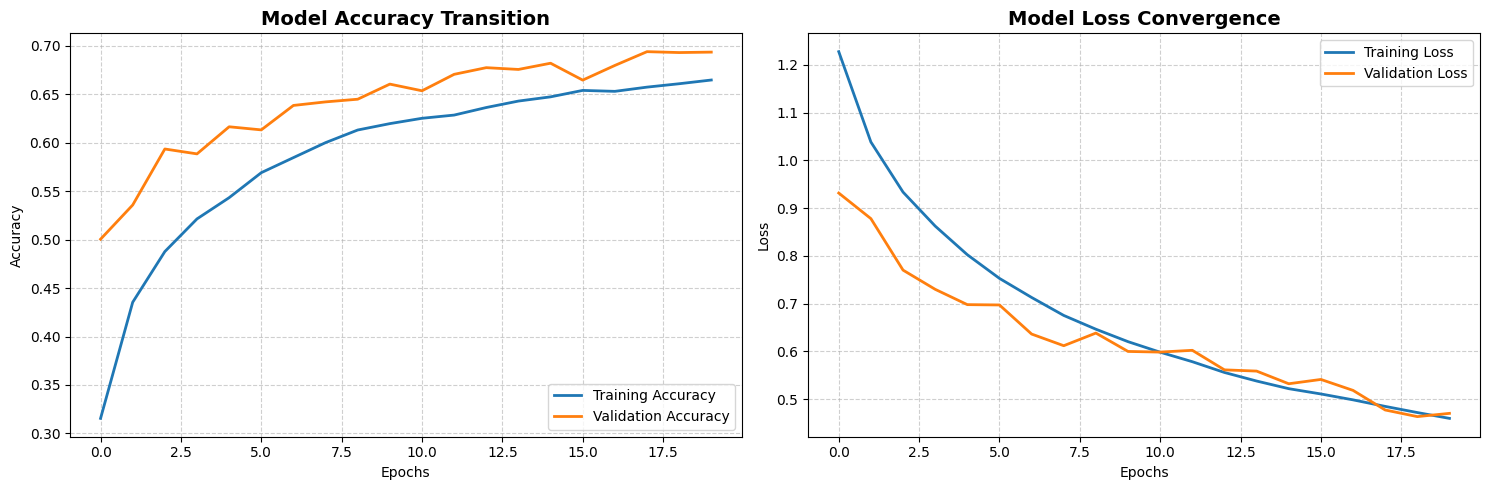

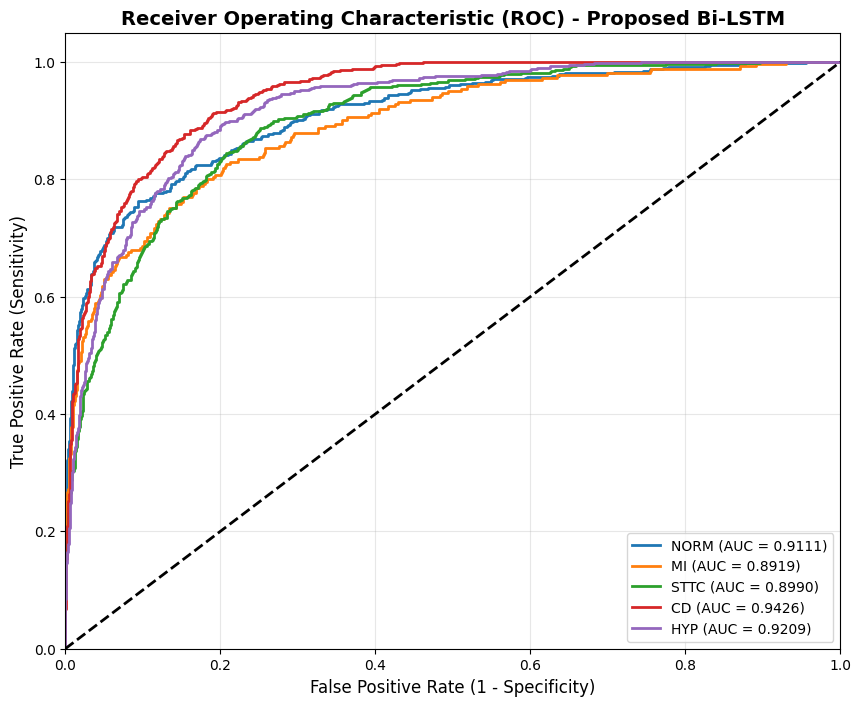

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# 1. Plotting Accuracy & Loss (Training History)
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy Plot
    ax1.plot(history.history['accuracy'], label='Training Accuracy', color='#1f77b4', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', linewidth=2)
    ax1.set_title('Model Accuracy Transition', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend(loc='lower right')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Loss Plot
    ax2.plot(history.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
    ax2.set_title('Model Loss Convergence', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# 2. Plotting Multi-class ROC Curve
def plot_roc_curve(model, X_test, y_test, class_names):
    y_pred_probs = model.predict(X_test, verbose=0)
    
    plt.figure(figsize=(10, 8))
    
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    plt.title('Receiver Operating Characteristic (ROC) - Proposed Bi-LSTM', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# --- Execution ---
class_names_final = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

# History plot (Loss and Accuracy)
plot_training_history(history_bilstm)

# ROC Curve plot
plot_roc_curve(model_bilstm, X_test, y_test, class_names_final)

In [ ]:
from sklearn.metrics import classification_report, precision_recall_fscore_support
import pandas as pd

def get_performance_matrix(model, X_test, y_test, class_names):
    # Predictions (0.5 threshold)
    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > 0.5).astype(int)
    
    # Calculate Metrics
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)
    
    # Create Table
    matrix = pd.DataFrame({
        'Class': class_names,
        'Precision': precision * 100,
        'Recall': recall * 100,
        'F1-Score': f1 * 100
    })
    
    # Add Macro Average
    macro_metrics = precision_recall_fscore_support(y_test, y_pred, average='macro')
    matrix.loc[len(matrix)] = ['Macro Avg', macro_metrics[0]*100, macro_metrics[1]*100, macro_metrics[2]*100]
    
    return matrix

# --- Execute ---
class_names = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
performance_df = get_performance_matrix(model_bilstm, X_test, y_test, class_names)
print(performance_df.round(2))

NameError: name 'model_bilstm' is not defined

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ==========================================
# 1. ARCHITECTURE: Residual Block
# ==========================================
def residual_block(x, filters, dilation_rate=1):
    shortcut = x
    x = layers.SeparableConv1D(filters, 3, padding='same', dilation_rate=dilation_rate)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)  

    x = layers.SeparableConv1D(filters, 3, padding='same', dilation_rate=dilation_rate)(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

# ==========================================
# 2. PROPOSED MODEL: CNN + Bi-LSTM + MHA
# ==========================================
def build_bilstm_attention_model(input_shape=(1000, 12), num_classes=5):
    inputs = layers.Input(shape=input_shape)

    # Spatial Layer (CNN)
    x = layers.Conv1D(64, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = residual_block(x, 64)
    x = layers.MaxPooling1D(2)(x)
    x = residual_block(x, 128, dilation_rate=2)
    x = layers.MaxPooling1D(2)(x)
    x = residual_block(x, 256, dilation_rate=4)

    # Temporal Layer (Bi-LSTM) - cuDNN compatible
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.2)
    )(x)

    # Multi-Head Attention
    attention_out = layers.MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    x = layers.Add()([x, attention_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # Global Feature Aggregation
    avg_pool = layers.GlobalAveragePooling1D()(x)
    max_pool = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([avg_pool, max_pool])

    # Classification Head
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.6)(x)

    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    return model

# ==========================================
# 3. EXECUTION & COMPILATION
# ==========================================
model_bilstm = build_bilstm_attention_model()

# Wapas Binary Crossentropy par for 90+ AUC
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5, clipnorm=1.0)
model_bilstm.compile(
    optimizer=optimizer,
    loss='binary_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

# Callbacks: Saving the best model based on val_auc
checkpoint_bilstm = ModelCheckpoint(
    'best_bilstm_model_final.h5',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Start Training
history_bilstm = model_bilstm.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr, checkpoint_bilstm],
    shuffle=True
)